# Grouping Comparison Experiment

Compares five alert-grouping methods (fixed window, time-delta, CSCAS-style,
AlertBERT, DeepCASE) on the held-out test scenarios (`fox`,
`russellmitchell`): alert volume reduction, group size distribution, group
purity, and (DeepCASE only) the fraction of alerts rejected outright rather
than grouped (`ungroupable_fraction`).

Each method's sweep now runs as its own standalone script
(`src/thesis/baselines/grouping/*.py`) rather than inline in this notebook
-- this notebook only loads their `results/*.json` (+ `*_sizes.npz`)
artifacts and plots them. See `run_grouping.sh` in that directory to run
every script overnight; the `GROUPING_DEVICE` env var selects `mps`/`cuda`/
`cpu` (default: auto-detect) for the two torch-based methods.

**Run the scripts first** to generate the artifacts this notebook reads:
```
cd src/thesis/baselines/grouping
python fixed_window.py
python time_delta.py
python cscas_grouping.py
python cscas_grouping_sensitivity.py
python deepcase_sweep.py
```
`alertbert_sweep.py` needs the separate `thesis-alertbert` conda env
(`alertbert.models` hard-imports `graph_tool`, not part of this project's
plain `venv/`):
```
conda activate thesis-alertbert
KMP_DUPLICATE_LIB_OK=TRUE python alertbert_sweep.py
```
This notebook itself only needs the plain venv -- it never imports
`thesis.grouping`/`torch`/`alertbert`/`deepcase`.


## 1. Imports

In [39]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from thesis.baselines.grouping._results import (
    load_grouping_results,
    load_group_size_arrays,
)

## 2. Settings

Edit and re-run -- nothing past this cell needs to change.


In [40]:
# The 5 methods that feed the shared cross-method comparison (each has a
# results/{name}.json + results/{name}_sizes.npz, written by the
# like-named script in src/thesis/baselines/grouping/).
GROUPING_RESULT_NAMES = ["fixed_window", "time_delta", "cscas_grouping", "alertbert", "deepcase"]

# CSCAS's authors' own validated production settings -- must match the
# primary config baked into cscas_grouping.py/cscas_grouping_sensitivity.py.
# Only used here for the sensitivity plot's reference lines.
CSCAS_SESSION_LENGTH_SECONDS = 300.0
CSCAS_SESSION_TIMEOUT_SECONDS = 60.0

# Shared across every scenario-aware plot below so "fox" reads as the same
# color/marker everywhere in this notebook.
SCENARIO_COLORS = {"fox": "#4477AA", "russellmitchell": "#EE6677"}
SCENARIO_MARKERS = {"fox": "o", "russellmitchell": "^"}


# --- Best-setting selection guards (section 9) ----------------------------
# `best_settings` (section 9) picks, per method, the highest MEAN-reduction
# swept configuration THAT ALSO clears these guards on EVERY test scenario.
# Without them, reduction-argmax walks straight into the degenerate operating
# points cells 35/37 warn about -- one runaway group => reduction -> 1.0 and
# mixed_frac -> 1.0 -- and that setting would then drive the whole section
# 10-11 scorecard.
#
# Tuned for the downstream miner this grouping feeds: attribute CONTRAST
# mining (thesis.mining.attribute_contrast_mining). That miner collapses each
# alert group to ONE feature row -- compute_candidate_attribute_features()
# reads pre-aggregated AlertGroup fields, with no per-alert loop -- and
# enumerates a fixed ~few-dozen-column candidate space, so its cost is
# O(n_groups), NOT group size: a 400k-alert group is a single O(1) row. What
# actually degrades contrast mining:
#   * mixed groups      -- each group carries ONE label, so a mixed group
#                          feeds the wrong class's feature values into the
#                          contrast statistics
#   * incoherent groups -- the single feature row (one `category`, one
#                          `proto`, ...) is a blurred average once the group
#                          spans many signatures, so mined predicates lose
#                          sharpness
#   * too few groups    -- too few rows, and too few attack rows, for
#                          growth_rate / chi-square to mean anything
# Set any guard to None to disable it.
SELECT_MAX_MIXED_FRAC = 0.02                 # label-noise ceiling (primary)
SELECT_MAX_SIGNATURE_DIVERSITY_MEAN = 2.5    # per-group feature-row crispness
SELECT_MIN_N_GROUPS = 200                    # statistical-power floor
# group_size_max only bites a miner whose cost scales with group size
# (itemset / tid-list mining, e.g. eclat) -- irrelevant to contrast mining,
# so left off here. Set to e.g. 100_000 when feeding an itemset miner.
SELECT_MAX_GROUP_SIZE_MAX = None


## 3. Loading

Tolerant of missing artifacts (prints `[skip] ...` and continues) -- run
whichever scripts you have, this notebook plots whatever's available.


In [41]:
results_dfs: dict[str, pd.DataFrame] = {}
size_arrays: dict[tuple, np.ndarray] = {}
for name in GROUPING_RESULT_NAMES:
    try:
        results_dfs[name] = load_grouping_results(name)
        size_arrays.update(load_group_size_arrays(name))
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results_dfs.keys())}")

# Derived columns needed by the per-method diagnostic plots below -- moved
# here from what used to be inline sweep cells.
if "time_delta" in results_dfs:
    results_dfs["time_delta"]["delta"] = results_dfs["time_delta"]["param"].astype(float)
if "deepcase" in results_dfs:
    results_dfs["deepcase"]["context_length"] = (
        results_dfs["deepcase"]["param"].str.extract(r"L=(\d+)").astype(int)
    )
    results_dfs["deepcase"]["eps"] = (
        results_dfs["deepcase"]["param"].str.extract(r"eps=([\d.]+)").astype(float)
    )
if "alertbert" in results_dfs:
    results_dfs["alertbert"]["delta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"d=([\d.]+)").astype(float)
    )
    results_dfs["alertbert"]["theta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"t=([\d.]+)").astype(float)
    )

all_results_df = (
    pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()
)

try:
    cscas_sensitivity_df = load_grouping_results("cscas_grouping_sensitivity")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    cscas_sensitivity_df = pd.DataFrame()

try:
    manual_review_df = load_grouping_results("deepcase_manual_review")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    manual_review_df = pd.DataFrame()


Loaded results for: ['fixed_window', 'time_delta', 'cscas_grouping', 'alertbert', 'deepcase']


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/2890516554.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()


## 3b. Per-setting results table (helper)

`settings_table` is used at the end of every method section (4–8). It
reports, for **each setting tested** (every swept configuration × scenario,
and — where the method has one — the global vs. per-host variant; *not* the
single jointly-best operating point picked later in section 9):

| column | meaning |
|---|---|
| `reduction` | alert volume reduction — proportion of alerts that no longer need individual review, per scenario and host variant |
| `group_size_mean` / `_median` / `_max` | alerts per group; median and max alongside the mean because a method can post a high reduction simply by emitting one enormous group |
| `group_size_max_over_median` | max ÷ median group size — an explicit **tail-heaviness** ratio. A distribution can be heavy-tailed at *every* setting; this shows whether the tail also gets *relatively* heavier (not just absolutely bigger) as the grouping knob loosens |
| `signature_diversity_mean` / `_max` | distinct detector signatures per group, mean over groups and for the single most heterogeneous group — lets the tail be read as "one signature repeating" vs. "unrelated activity colliding" |
| `host_purity` | fraction of groups whose alerts all come from one host — for the global variants, drops as the window/gap grows iff bigger groups are pulling in multiple hosts |
| `pure_benign_frac` / `pure_attack_frac` / `mixed_frac` | fraction of groups that are pure-benign, pure-attack, or mixed, by AIT-ADS label |

`signature_diversity_max` is the most signature-diverse group, which is
*not* guaranteed to be the largest group — a conclusive "the biggest group
spans N signatures" needs a per-group metric that isn't persisted. These
columns support the hedged reading, not that one.

These tables are the numeric backing for the diagnostic plots above them;
they do not feed `all_results_df` or the section 9 comparison.

Every method section (4–8) and every cross-method table (9–11) also prints a
**`booktabs` LaTeX version** (helper `to_latex_table`, section 3c) with the
**same columns** as the displayed table (`_PER_SETTING_LATEX_METRICS`, which
defaults to every metric). Nothing is written to disk. The full table is
wide — the 168-row longtables (time-delta / AlertBERT / DeepCASE) will want
a landscape page or `\footnotesize` in the thesis; trim
`_PER_SETTING_LATEX_METRICS`, or pass `latex_metrics=` for one table, if
needed.


In [42]:
# Columns every end-of-section table reports (see section 3b). In order:
#   reduction;
#   group size mean / median / max, plus max/median as an explicit
#     tail-heaviness ratio (the max alone hides that a distribution can be
#     heavy-tailed at every setting and get *relatively* heavier as the
#     grouping knob loosens -- not just absolutely bigger);
#   signature diversity mean / max and host purity -- so the tail can be
#     read as "one signature/host repeating" vs. "unrelated activity
#     colliding" (all three already emitted per setting by _metrics.py);
#   group purity as pure-benign / pure-attack / mixed fractions.
PER_SETTING_METRICS = [
    "reduction",
    "group_size_mean",
    "group_size_median",
    "group_size_max",
    "group_size_max_over_median",
    "signature_diversity_mean",
    "signature_diversity_max",
    "host_purity",
    "pure_benign_frac",
    "pure_attack_frac",
    "mixed_frac",
]

# The LaTeX version prints the SAME columns as the displayed table (all of
# PER_SETTING_METRICS). This is wide -- on the 168-row longtables (time-delta
# / AlertBERT / DeepCASE) it will need a landscape page or \footnotesize /
# adjustbox in the thesis. Trim this list (or pass `latex_metrics=` to
# settings_table) if a specific table needs to be narrower.
_PER_SETTING_LATEX_METRICS = list(PER_SETTING_METRICS)

_PER_SETTING_ROUNDING = {
    "reduction": 4,
    "group_size_mean": 1,
    "group_size_median": 1,
    "group_size_max_over_median": 0,
    "signature_diversity_mean": 2,
    "signature_diversity_max": 0,
    "host_purity": 3,
    "pure_benign_frac": 4,
    "pure_attack_frac": 4,
    "mixed_frac": 4,
}


def settings_table(
    df: pd.DataFrame,
    id_cols: list[str],
    sort_cols: list[str] | None = None,
    title: str = "",
    latex_caption: str = "",
    latex_label: str = "",
    latex_longtable: bool = False,
    latex_metrics: list[str] | None = None,
) -> pd.DataFrame:
    """
    Render one method section's per-setting results table -- one row per
    setting tested, columns PER_SETTING_METRICS (see section 3b).

    `id_cols` become the row index; `sort_cols` (default `id_cols`) order
    the rows and may name helper columns that aren't shown in the table
    itself (e.g. a numeric sort key for a string `param`). Returns the
    table and also displays it with every row visible.

    `group_size_max_over_median` is derived here (not stored) -- max / median
    group size, NaN where median is 0.

    When `latex_caption` is given, a booktabs LaTeX version is also printed
    (via `to_latex_table`, section 3c) with the columns in `latex_metrics`
    (default `_PER_SETTING_LATEX_METRICS` = every PER_SETTING_METRICS column).
    Pass `latex_longtable=True` for the long sweeps (time-delta, AlertBERT,
    DeepCASE); pass a shorter `latex_metrics=` list for one that must be
    narrower.
    """
    df = df.assign(
        group_size_max_over_median=lambda d: d["group_size_max"].div(
            d["group_size_median"].where(d["group_size_median"] > 0)
        )
    )
    table = (
        df.sort_values(list(sort_cols or id_cols))
        .set_index(id_cols)[PER_SETTING_METRICS]
        .round(_PER_SETTING_ROUNDING)
    )
    if title:
        print(title)
    with pd.option_context("display.max_rows", None):
        display(table)
    if latex_caption:
        # LaTeX only: show the four fraction columns as percentages on two
        # decimals ("(\%)" in the header, bare number in the cell). The
        # displayed DataFrame and the return value keep the raw fractions.
        _pct = {"pure_benign_frac": "pure_benign_pct",
                "pure_attack_frac": "pure_attack_pct",
                "mixed_frac": "mixed_pct", "host_purity": "host_purity_pct"}
        latex_table = table[latex_metrics or _PER_SETTING_LATEX_METRICS].copy()
        for _frac, _pctcol in _pct.items():
            if _frac in latex_table.columns:
                latex_table[_frac] = latex_table[_frac] * 100.0
        latex_table = latex_table.rename(
            columns={k: v for k, v in _pct.items() if k in latex_table.columns}
        )
        print(to_latex_table(
            latex_table,
            caption=latex_caption,
            label=latex_label,
            longtable=latex_longtable,
        ))
    return table


## 3c. LaTeX table export

`to_latex_table(df, *, caption, label, ...)` renders a DataFrame as a
`booktabs` LaTeX table in the same house style as
`ait_ads_baseline_comparison.ipynb` / `cscas_baseline_comparison.ipynb` and
returns the string. Every table section below prints its LaTeX right after
the rendered DataFrame; nothing is written to disk.

**Preamble the output assumes:** `\usepackage{booktabs}` throughout;
`\usepackage{graphicx}` for the wide section 9 / 11 tables (wrapped in
`\resizebox`); `\usepackage{longtable}` for the long per-setting sweeps
(time-delta, AlertBERT, DeepCASE). Column headers are prettified and
per-column decimal places are set via `_LATEX_COL_RENAME` /
`_LATEX_COL_DECIMALS` — edit those to taste.

In [43]:
import re


_LATEX_NA = "--"
_NUMERIC_STR = re.compile(r"^-?\d+(?:\.\d+)?$")

# Pretty headers for column / index-level names. Anything not listed is used
# verbatim, with LaTeX specials escaped.
_LATEX_COL_RENAME = {
    "reduction": "Reduction", "reduction_mean": "Reduction", "coverage": "Coverage",
    "group_size_mean": "Size mean", "group_size_median": "Size med.",
    "group_size_max": "Size max", "group_size_max_over_median": "Max/med.",
    "n_groups": r"\#groups",
    "pure_benign_frac": "Pure-benign", "pure_attack_frac": "Pure-attack",
    "mixed_frac": "Mixed", "host_purity": "Host purity", "ungroupable_fraction": "Ungroupable",
    "pure_benign_pct": r"Pure-benign (\%)", "pure_attack_pct": r"Pure-attack (\%)",
    "mixed_pct": r"Mixed (\%)", "host_purity_pct": r"Host purity (\%)",
    "signature_diversity_mean": "Sig.\\ div.", "signature_diversity_max": "Sig.\\ div.\\ max",
    "temporal_span_mean": "Span (s)",
    "minority_label_exposure": "Minority exp.", "train_time_seconds": "Train (s)",
    "inference_time_seconds": "Infer (s)", "gap": "Gap", "gpu_required": "GPU",
    "extra_deps": "Extra deps", "has_rejection_path": "Rejects?",
    "passes_operational": "Op. fit", "passes_reduction": "G1", "passes_purity": "G2",
    "passes_generalization": "G3", "n_gates_passed": r"\#gates", "verdict": "Verdict",
    "n_groups_mean": r"\#groups", "n_pure_attack_groups": r"\#pure-atk",
    "authors_validated": "Authors' cfg", "context_length": "$L$",
    "eps": r"$\varepsilon$", "delta": r"$\delta$ (s)", "theta": r"$\theta$ (s)",
    "scenario": "Scenario", "method": "Method", "param": "Param", "setting": "Setting",
    "window_s": "Window size (s)", "a": r"$a$", "i": r"$i$",
}
# Fixed decimal places per metric column; columns not listed use the call's
# `decimals` argument.
_LATEX_COL_DECIMALS = {
    "group_size_mean": 1, "group_size_median": 1, "group_size_max": 0, "n_groups": 0,
    "temporal_span_mean": 1, "signature_diversity_mean": 2, "train_time_seconds": 1,
    "inference_time_seconds": 2, "n_gates_passed": 0, "n_groups_mean": 0,
    "n_pure_attack_groups": 0, "group_size_max_over_median": 0,
    "signature_diversity_max": 0, "host_purity": 3,
    "pure_benign_pct": 2, "pure_attack_pct": 2, "mixed_pct": 2, "host_purity_pct": 2,
}


def _tex_escape(s) -> str:
    s = str(s)
    if "$" in s or "\\" in s:  # already math / a macro -- leave alone
        return s
    for a, b in (("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"),
                 ("#", r"\#"), ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
                 ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")):
        s = s.replace(a, b)
    return s


def _fmt_index(v) -> str:
    """Row-label cell: compact, no thousands separators, no forced decimals."""
    if v is None or (isinstance(v, float) and pd.isna(v)) or v is pd.NA:
        return _LATEX_NA
    if isinstance(v, (bool, np.bool_)):
        return "yes" if v else "no"
    if isinstance(v, str):
        return f"{float(v):g}" if _NUMERIC_STR.match(v.strip()) else _tex_escape(v)
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    f = float(v)
    return str(int(f)) if f.is_integer() else f"{f:g}"


def _fmt_value(v, decimals: int) -> str:
    """Data cell: fixed `decimals`, thousands separators, NaN/None -> --."""
    if v is None or (isinstance(v, float) and pd.isna(v)) or v is pd.NA:
        return _LATEX_NA
    if isinstance(v, (bool, np.bool_)):
        return "yes" if v else "no"
    if isinstance(v, str):
        return _tex_escape(v)
    f = float(v)
    if not np.isfinite(f):
        return _LATEX_NA
    return f"{f:,.{decimals}f}"


def to_latex_table(df, *, caption: str, label: str, decimals: int = 3,
                   longtable: bool = False, resizebox: bool = False,
                   rename: bool = True, group_rule: bool = True) -> str:
    """
    Booktabs LaTeX for `df`, in the house style of the ait_ads / cscas
    baseline notebooks. Returns the string; the caller prints it.

    - MultiIndex row labels render as leading columns, repeats blanked, with
      a \\midrule between top-level groups (`group_rule`).
    - `decimals` is the default fixed decimal places for numeric cells;
      `_LATEX_COL_DECIMALS` overrides it per metric.
    - `longtable=True` -> a bare `longtable` (no float wrapper, no resizebox),
      for tables too long for one page.
    - `resizebox=True` -> scale a wide `tabular` to \\textwidth (needs graphicx).
    """
    d = df.to_frame() if isinstance(df, pd.Series) else df.copy()
    n_lvl = d.index.nlevels
    idx_names = list(d.index.names) if n_lvl > 1 else [d.index.name]
    idx_names = ["" if n is None else n for n in idx_names]

    def hdr(name):
        return _LATEX_COL_RENAME.get(name, _tex_escape(name)) if rename else _tex_escape(name)

    col_dec = [_LATEX_COL_DECIMALS.get(c, decimals) for c in d.columns]
    header = " & ".join([hdr(n) for n in idx_names] + [hdr(c) for c in d.columns]) + r" \\"
    col_fmt = "l" * n_lvl + "r" * len(d.columns)
    ncol = n_lvl + len(d.columns)

    body, prev = [], None
    for key, row in zip(d.index, d.itertuples(index=False, name=None)):
        kt = key if isinstance(key, tuple) else (key,)
        lead, diverged = [], False
        for i, val in enumerate(kt):
            if diverged or prev is None or prev[i] != kt[i]:
                lead.append(_fmt_index(val))
                diverged = True
            else:
                lead.append("")
        if group_rule and n_lvl > 1 and prev is not None and prev[0] != kt[0]:
            body.append(r"\midrule")
        body.append(" & ".join(lead + [_fmt_value(v, col_dec[j]) for j, v in enumerate(row)]) + r" \\")
        prev = kt

    if longtable:
        return "\n".join([
            rf"\begin{{longtable}}{{{col_fmt}}}",
            rf"\caption{{{caption}}}\label{{{label}}}\\",
            r"\toprule", header, r"\midrule", r"\endfirsthead",
            rf"\multicolumn{{{ncol}}}{{c}}{{\tablename\ \thetable\ (continued)}}\\",
            r"\toprule", header, r"\midrule", r"\endhead",
            r"\midrule",
            rf"\multicolumn{{{ncol}}}{{r}}{{\emph{{continued on next page}}}}\\",
            r"\endfoot", r"\bottomrule", r"\endlastfoot", *body, r"\end{longtable}",
        ])

    tab = "\n".join([rf"\begin{{tabular}}{{{col_fmt}}}", r"\toprule", header,
                     r"\midrule", *body, r"\bottomrule", r"\end{tabular}"])
    if resizebox:
        tab = "\\resizebox{\\textwidth}{!}{%\n" + tab + "%\n}"
    return "\n".join([r"\begin{table}[htbp]", r"\centering", r"\small",
                      rf"\caption{{{caption}}}", rf"\label{{{label}}}", tab,
                      r"\end{table}"])

## 4. Fixed window

Linear sweep (this method's parameter is an absolute group size, not a
gap threshold, so no log-scale sweep here — see the time-delta section
for why that distinction matters).


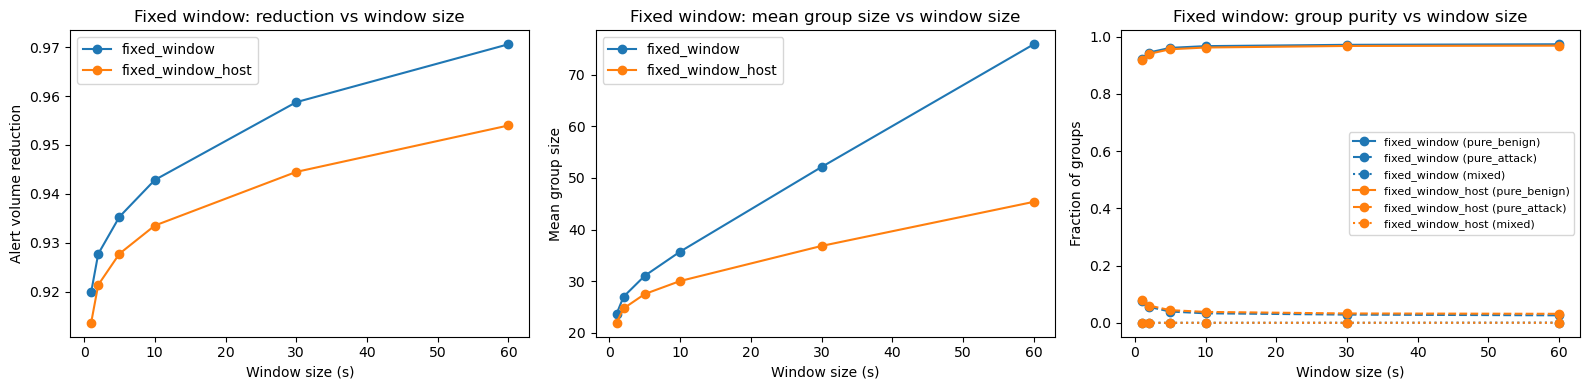

In [44]:
import itertools

fixed_window_df = results_dfs.get("fixed_window")
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["reduction"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[0].plot(agg["param"], agg["reduction"], marker="o", label=method_name)

    ax[0].set_xlabel("Window size (s)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Fixed window: reduction vs window size")
    ax[0].legend()

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["group_size_mean"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[1].plot(agg["param"], agg["group_size_mean"], marker="o", label=method_name)

    ax[1].set_xlabel("Window size (s)")
    ax[1].set_ylabel("Mean group size")
    ax[1].set_title("Fixed window: mean group size vs window size")
    ax[1].legend()

    # Group purity vs window size -- one color per method, one linestyle
    # per purity fraction (pure-benign / pure-attack / mixed all sum to 1
    # per setting, so the three curves are directly comparable).
    _purity_cols = ["pure_benign_frac", "pure_attack_frac", "mixed_frac"]
    _purity_styles = {"pure_benign_frac": "-", "pure_attack_frac": "--", "mixed_frac": ":"}
    _color_cycle = itertools.cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

    for method_name, group in fixed_window_df.groupby("method"):
        color = next(_color_cycle)
        agg = group.groupby("param", as_index=False)[_purity_cols].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        for col in _purity_cols:
            ax[2].plot(
                agg["param"],
                agg[col],
                marker="o",
                linestyle=_purity_styles[col],
                color=color,
                label=f"{method_name} ({col.replace('_frac', '')})",
            )

    ax[2].set_xlabel("Window size (s)")
    ax[2].set_ylabel("Fraction of groups")
    ax[2].set_title("Fixed window: group purity vs window size")
    ax[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


In [45]:
# Every fixed-window setting tested: both variants (global `fixed_window`,
# per-host `fixed_window_host`), all six window sizes, both scenarios.
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    fixed_window_settings_table = settings_table(
        fixed_window_df.assign(window_s=lambda d: d["param"].astype(int)),
        id_cols=["scenario", "method", "window_s"],
        sort_cols=["scenario", "method", "window_s"],
        title="Fixed window -- every setting tested",
        latex_caption=(
            "Fixed-window grouping: every setting tested (global and per-host "
            "variant, all six window sizes, both held-out test scenarios)."
        ),
        latex_label="tab:grouping-fixed-window-settings",
    )

Fixed window -- every setting tested


reduction  group_size_mean  \
scenario        method            window_s                               
fox             fixed_window      1            0.9750             39.9   
                                  2            0.9782             45.9   
                                  5            0.9812             53.1   
                                  10           0.9837             61.3   
                                  30           0.9889             90.2   
                                  60           0.9924            132.2   
                fixed_window_host 1            0.9730             37.1   
                                  2            0.9762             42.0   
                                  5            0.9787             47.0   
                                  10           0.9805             51.3   
                                  30           0.9842             63.2   
                                  60           0.9872             78.1   
russellmitchell fixed_window      1            0.8647              7.4   
                                  2            0.8772              8.1   
                                  5            0.8894              9.0   
                                  10           0.9020             10.2   
                                  30           0.9286             14.0   
                                  60           0.9488             19.5   
                fixed_window_host 1            0.8542              6.9   
                                  2            0.8665              7.5   
                                  5            0.8768              8.1   
                                  10           0.8865              8.8   
                                  30           0.9048             10.5   
                                  60           0.9208             12.6   

                                            group_size_median  group_size_max  \
scenario        method            window_s                                      
fox             fixed_window      1                       3.0             772   
                                  2                       3.0            1527   
                                  5                       3.0            3163   
                                  10                      3.0            6027   
                                  30                      6.0           11325   
                                  60                      9.0           22117   
                fixed_window_host 1                       3.0             772   
                                  2                       3.0            1527   
                                  5                       3.0            3163   
                                  10                      3.0            6021   
                                  30                      3.0           11325   
                                  60                      6.0           22117   
russellmitchell fixed_window      1                       3.0             712   
                                  2                       3.0            1358   
                                  5                       3.0            3069   
                                  10                      3.0            5693   
                                  30                      6.0            5957   
                                  60                      8.0            5961   
                fixed_window_host 1                       3.0             712   
                                  2                       3.0            1358   
                                  5                       3.0            3069   
                                  10                      3.0            5693   
                                  30                      3.0            5953   
                                  60                      6.0            5953   

            

\begin{table}[htbp]
\centering
\small
\caption{Fixed-window grouping: every setting tested (global and per-host variant, all six window sizes, both held-out test scenarios).}
\label{tab:grouping-fixed-window-settings}
\begin{tabular}{lllrrrrrrrrrrr}
\toprule
Scenario & Method & Window size (s) & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
fox & fixed\_window & 1 & 0.975 & 39.9 & 3.0 & 772 & 257 & 1.48 & 15 & 92.70 & 87.91 & 12.09 & 0.00 \\
 &  & 2 & 0.978 & 45.9 & 3.0 & 1,527 & 509 & 1.45 & 15 & 91.40 & 92.12 & 7.88 & 0.00 \\
 &  & 5 & 0.981 & 53.1 & 3.0 & 3,163 & 1,054 & 1.42 & 15 & 88.40 & 95.13 & 4.87 & 0.00 \\
 &  & 10 & 0.984 & 61.3 & 3.0 & 6,027 & 2,009 & 1.41 & 15 & 83.60 & 96.31 & 3.68 & 0.01 \\
 &  & 30 & 0.989 & 90.2 & 6.0 & 11,325 & 1,888 & 1.51 & 15 & 68.40 & 97.06 & 2.92 & 0.02 \\
 &  & 60 & 0.992 & 132.2 & 9.0 & 22,117 & 2,457 & 1.71 & 19 & 54.90 & 

### 4b. Where the tail comes from

Four views of the heavy right tail in the fixed-window group-size
distribution (all from the artifacts already loaded -- no rerun):

- **(a) largest group vs. window, global (FW) vs. per-host (FWH).** The two
  curves coincide at every window -- per-host splitting leaves the largest
  group *untouched*, so that group is already a single host's alerts. On
  `fox` the largest group grows with the window (a continuous stream); on
  `russellmitchell` it plateaus once the window covers the whole burst.
- **(b) median group vs. window.** Here FWH *does* sit below FW -- splitting
  fragments the many small groups, just not the tail.
- **(c, d) group-size survival curve** $P(\text{size} \ge x)$, log-log, one
  curve per window, largest group marked. The body (size $\lesssim 10$) is
  invariant to the window; only the tail edge moves -- rightward without
  limit on `fox`, to a fixed ceiling on `russellmitchell`.

Together: the tail is one high-rate (benign -- see the purity columns)
single-host stream that a wider fixed window simply sweeps more of into one
group; fixed-window has no per-group size cap to stop it, and per-host
splitting cannot help because the offending host already *is* the group.


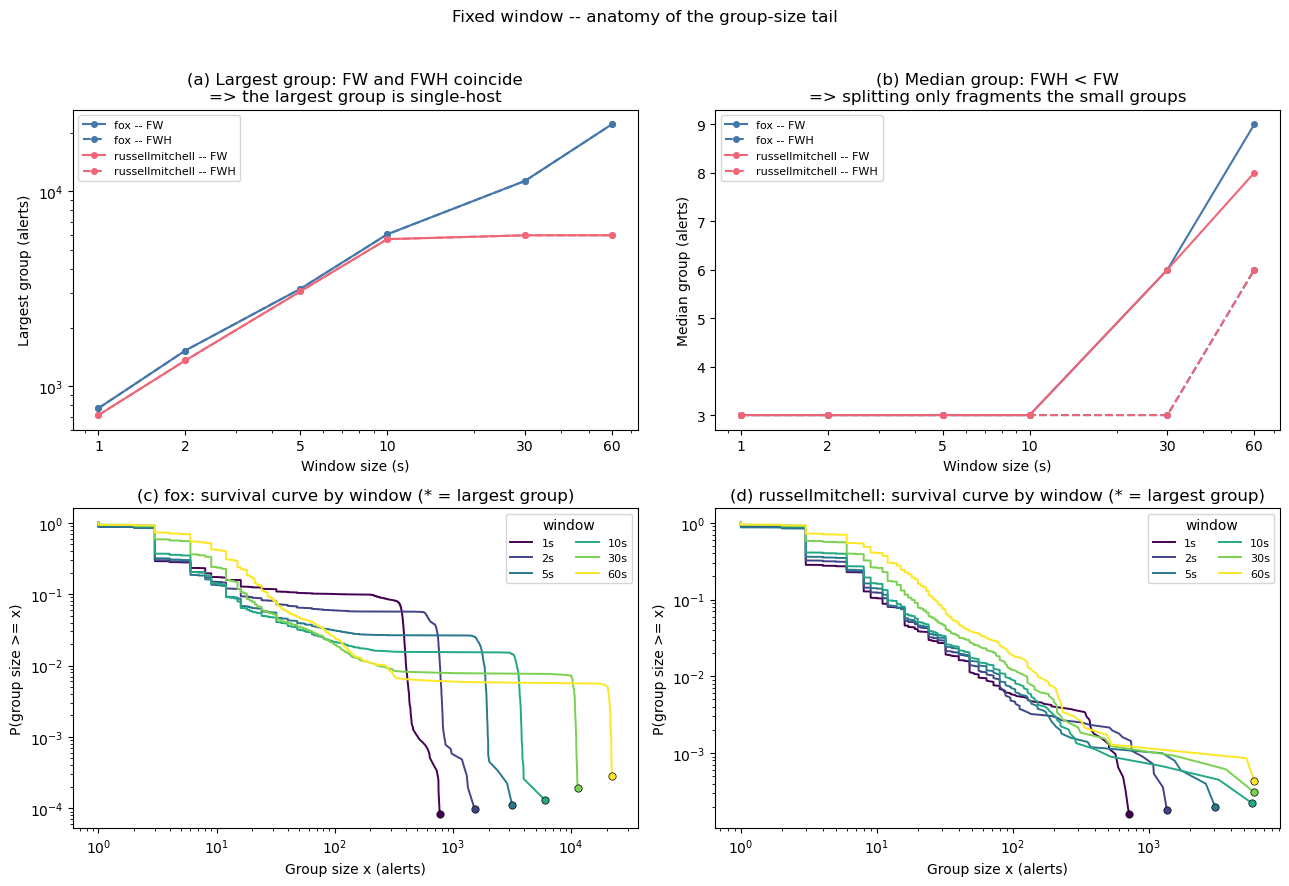

In [46]:
fixed_window_df = results_dfs.get("fixed_window")
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    _fw = fixed_window_df.assign(w=lambda d: d["param"].astype(int))
    _scenarios = sorted(_fw["scenario"].unique())
    _windows = sorted(_fw["w"].unique())
    _variants = [("fixed_window", "FW", "-"), ("fixed_window_host", "FWH", "--")]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) largest group, (b) median group -- vs window, FW vs FWH
    for ax, col, lab, logy in [(axes[0, 0], "group_size_max", "Largest group (alerts)", True),
                               (axes[0, 1], "group_size_median", "Median group (alerts)", False)]:
        for scen in _scenarios:
            for method, mlab, ls in _variants:
                g = (_fw[(_fw["method"] == method) & (_fw["scenario"] == scen)]
                     .sort_values("w"))
                ax.plot(g["w"], g[col], ls=ls, marker="o", ms=4,
                        color=SCENARIO_COLORS.get(scen, "grey"),
                        label=f"{scen} -- {mlab}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_xticks(_windows)
        ax.set_xticklabels(_windows)
        ax.set_xlabel("Window size (s)")
        ax.set_ylabel(lab)
        ax.legend(fontsize=8)
    axes[0, 0].set_title("(a) Largest group: FW and FWH coincide\n=> the largest group is single-host")
    axes[0, 1].set_title("(b) Median group: FWH < FW\n=> splitting only fragments the small groups")

    # (c, d) group-size survival curve per window, one scenario each
    _cmap = plt.get_cmap("viridis")
    _wcolors = {w: _cmap(k / max(1, len(_windows) - 1)) for k, w in enumerate(_windows)}
    for ax, scen in zip((axes[1, 0], axes[1, 1]), _scenarios):
        for w in _windows:
            arr = size_arrays.get(("fixed_window", str(w), scen))
            if arr is None or len(arr) == 0:
                continue
            s = np.sort(np.asarray(arr))
            surv = np.arange(len(s), 0, -1) / len(s)   # P(size >= s[i])
            ax.plot(s, surv, color=_wcolors[w], lw=1.4, label=f"{w}s")
            ax.scatter([s[-1]], [1 / len(s)], color=_wcolors[w], s=28,
                       edgecolor="black", linewidth=0.5, zorder=5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Group size x (alerts)")
        ax.set_ylabel("P(group size >= x)")
        ax.set_title(f"({'c' if scen == _scenarios[0] else 'd'}) {scen}: survival curve by window "
                     f"(* = largest group)")
        ax.legend(fontsize=8, title="window", ncol=2)

    fig.suptitle("Fixed window -- anatomy of the group-size tail", fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


## 5. Time-delta

Log-scale sweep matching the original method's own validated evaluation
protocol: `delta = a * 2**i` for `i = -7 ... 13`, `a in {1, 1.5}`. This
range spans sub-second to multi-hour gaps, which matters specifically
because AIT-ADS alerts have whole-second timestamp resolution for many
detectors — a coarser, linear sweep would miss the discontinuity around
delta = 1s entirely.


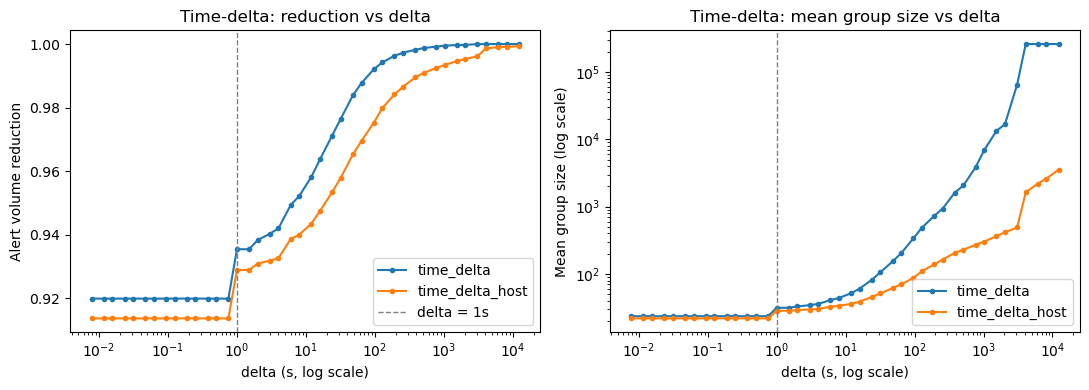

In [47]:
time_delta_df = results_dfs.get("time_delta")
if time_delta_df is None:
    print("[skip] time_delta not loaded -- run time_delta.py first")
else:
    # Per-method diagnostic plot: log-x reduction curve, flags the delta=1s
    # discontinuity described above.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["reduction"].mean().sort_values("delta")
        ax[0].plot(agg["delta"], agg["reduction"], marker=".", label=method_name)

    ax[0].set_xscale("log")
    ax[0].axvline(1.0, color="grey", linestyle="--", linewidth=1, label="delta = 1s")
    ax[0].set_xlabel("delta (s, log scale)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Time-delta: reduction vs delta")
    ax[0].legend()

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["group_size_mean"].mean().sort_values("delta")
        ax[1].plot(agg["delta"], agg["group_size_mean"], marker=".", label=method_name)

    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    ax[1].axvline(1.0, color="grey", linestyle="--", linewidth=1)
    ax[1].set_xlabel("delta (s, log scale)")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("Time-delta: mean group size vs delta")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


In [48]:
# Every time-delta setting tested: both variants (global `time_delta`,
# per-host `time_delta_host`), all 42 log-spaced delta values, both
# scenarios. Long by design (168 rows) -- the curves above are the visual
# summary; this is the numeric backing.
if time_delta_df is None:
    print("[skip] time_delta not loaded -- run time_delta.py first")
else:
    # Each swept gap threshold is delta = a * 2**i (a in {1, 1.5},
    # i in -7..13); recover (a, i) from the stored delta so the table indexes
    # by the generating parameters rather than the raw seconds value.
    _d = time_delta_df["delta"].to_numpy()
    _i1 = np.round(np.log2(_d))
    _i15 = np.round(np.log2(_d / 1.5))
    _use15 = np.abs(_d / 1.5 - 2.0 ** _i15) < np.abs(_d - 2.0 ** _i1)

    time_delta_settings_table = settings_table(
        time_delta_df.assign(
            a=np.where(_use15, 1.5, 1.0),
            i=np.where(_use15, _i15, _i1).astype(int),
            k=time_delta_df["delta"],
        ),
        id_cols=["scenario", "method", "a", "i"],
        sort_cols=["scenario", "method", "k"],
        title="Time-delta -- every setting tested",
        latex_caption=(
            "Time-delta grouping: every setting tested (global and per-host "
            "variant, both held-out test scenarios). Each gap threshold is "
            "$\\delta = a \\cdot 2^{i}$ seconds, with $a \\in \\{1, 1.5\\}$ "
            "and $i \\in \\{-7, \\dots, 13\\}$ (42 log-spaced values, "
            "$\\delta$ from $7.8\\,$ms to $12{,}288\\,$s)."
        ),
        latex_label="tab:grouping-time-delta-settings",
        latex_longtable=True,
    )


Time-delta -- every setting tested


reduction  group_size_mean  \
scenario        method          a   i                                 
fox             time_delta      1.0 -7      0.9750             39.9   
                                1.5 -7      0.9750             39.9   
                                1.0 -6      0.9750             39.9   
                                1.5 -6      0.9750             39.9   
                                1.0 -5      0.9750             39.9   
                                1.5 -5      0.9750             39.9   
                                1.0 -4      0.9750             39.9   
                                1.5 -4      0.9750             39.9   
                                1.0 -3      0.9750             39.9   
                                1.5 -3      0.9750             39.9   
                                1.0 -2      0.9750             39.9   
                                1.5 -2      0.9750             39.9   
                                1.0 -1      0.9750             39.9   
                                1.5 -1      0.9750             39.9   
                                1.0  0      0.9815             54.1   
                                1.5  0      0.9815             54.1   
                                1.0  1      0.9824             56.7   
                                1.5  1      0.9831             59.3   
                                1.0  2      0.9839             62.1   
                                1.5  2      0.9858             70.5   
                                1.0  3      0.9869             76.3   
                                1.5  3      0.9889             89.8   
                                1.0  4      0.9906            105.9   
                                1.5  4      0.9931            144.7   
                                1.0  5      0.9947            188.8   
                                1.5  5      0.9963            272.8   
                                1.0  6      0.9972            362.3   
                                1.5  6      0.9984            606.5   
                                1.0  7      0.9989            881.0   
                                1.5  7      0.9992           1303.3   
                                1.0  8      0.9994           1671.7   
                                1.5  8      0.9997           2938.5   
                                1.0  9      0.9997           3696.1   
                                1.5  9      0.9999           7061.3   
                                1.0  10     0.9999          12786.6   
                                1.5  10     1.0000          24900.2   
                                1.0  11     1.0000          31540.3   
                                1.5  11     1.0000         118276.0   
                                1.0  12     1.0000         473104.0   
                                1.5  12     1.0000         473104.0   
                                1.0  13     1.0000         473104.0   
                                1.5  13     1.0000         473104.0   
                time_delta_host 1.0 -7      0.9730             37.1   
                                1.5 -7      0.9730             37.1   
                                1.0 -6      0.9730             37.1   
                                1.5 -6      0.9730             37.1   
                                1.0 -5      0.9730             37.1   
                                1.5 -5      0.9730             37.1   
                                1.0 -4      0.9730             37.1   
                                1.5 -4      0.9730             37.1   
                                1.0 -3      0.9730             37.1   
                                1.5 -3      0.9730             37.1   
                                1.0 -2      0.9730             37.1   
                                1.5 -2      0.9730             37.1   
                                1.0 -1      0.9730             37

\begin{longtable}{llllrrrrrrrrrrr}
\caption{Time-delta grouping: every setting tested (global and per-host variant, both held-out test scenarios). Each gap threshold is $\delta = a \cdot 2^{i}$ seconds, with $a \in \{1, 1.5\}$ and $i \in \{-7, \dots, 13\}$ (42 log-spaced values, $\delta$ from $7.8\,$ms to $12{,}288\,$s).}\label{tab:grouping-time-delta-settings}\\
\toprule
Scenario & Method & $a$ & $i$ & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endfirsthead
\multicolumn{15}{c}{\tablename\ \thetable\ (continued)}\\
\toprule
Scenario & Method & $a$ & $i$ & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endhead
\midrule
\multicolumn{15}{r}{\emph{continued on next page}}\\
\endfoot
\bottomrule
\endlastfoot
fox & time\_delta & 1 & -7 & 0.975 & 

## 6. CSCAS grouping

CSCAS-style grouping (host + signature split, gap/span-capped sessions) is
**not swept**: it runs at the original authors' own validated production
settings -- `SessionLength = 300 s`, `SessionTimeout = 60 s` (Vaarandi &
Guerra-Manzanares 2024) -- and that single configuration is the one that
feeds the cross-method comparison in section 9.

The rest of this section is a **one-at-a-time robustness check** on those
two parameters (`cscas_grouping_sensitivity.py`, folded in here from what
used to be section 6b): `session_timeout ∈ {30, 60, 120}` with
`session_length` held at 300, then `session_length ∈ {150, 300, 600}` with
`session_timeout` held at 60. The question is whether the published
60 s / 300 s choice still makes sense now that CSCAS-style grouping has
been generalized here from Suricata-only to all three IDS sources -- it is
deliberately **not** a search for a better operating point, so these
sensitivity rows are kept out of `all_results_df` and section 9 (a
sensitivity setting must never compete with the validated config for
CSCAS's slot there). The authors' validated setting is flagged in the
per-setting table at the end of the section.

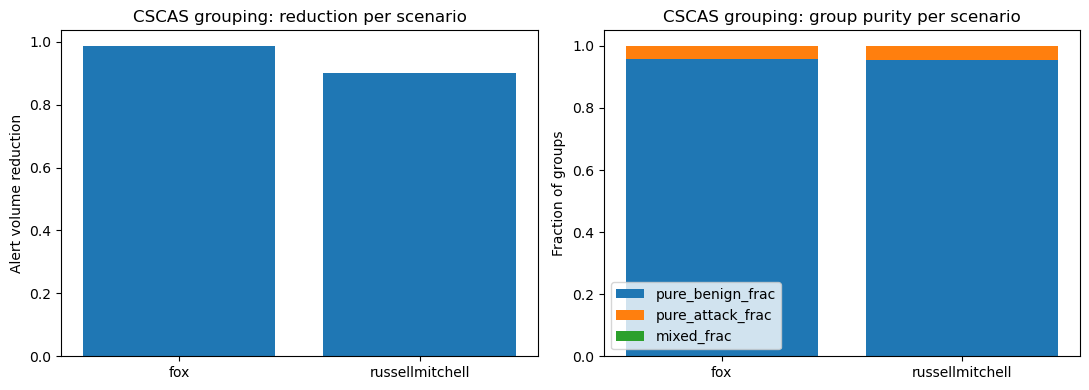

In [49]:
cscas_df = results_dfs.get("cscas_grouping")
if cscas_df is None:
    print("[skip] cscas_grouping not loaded -- run cscas_grouping.py first")
else:
    # Per-method diagnostic plot: reduction and purity per scenario (single config, so bars not curves)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].bar(cscas_df["scenario"], cscas_df["reduction"])
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("CSCAS grouping: reduction per scenario")

    purity_cols = ["pure_benign_frac", "pure_attack_frac", "mixed_frac"]
    bottom = np.zeros(len(cscas_df))
    for col in purity_cols:
        ax[1].bar(cscas_df["scenario"], cscas_df[col], bottom=bottom, label=col)
        bottom += cscas_df[col].values
    ax[1].set_ylabel("Fraction of groups")
    ax[1].set_title("CSCAS grouping: group purity per scenario")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


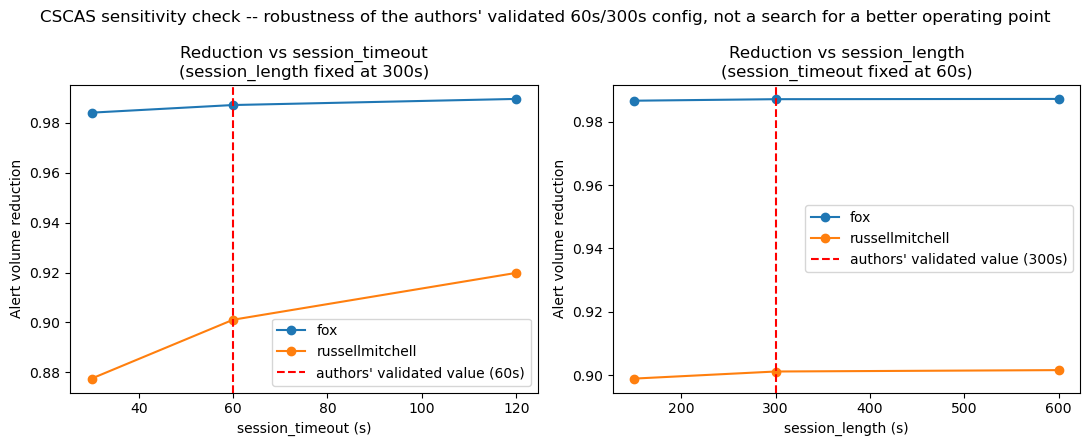

In [50]:
if cscas_sensitivity_df.empty:
    print("[skip] cscas_grouping_sensitivity not loaded -- run cscas_grouping_sensitivity.py first")
else:
    # Sensitivity diagnostic: reduction vs. each parameter, one-at-a-time,
    # with the authors' validated value marked -- a robustness check (does
    # the published config still make sense here), not a search for a
    # better operating point, so the plot deliberately doesn't highlight
    # any other point as "best." Group size / purity for these same
    # settings are in the per-setting table at the end of the section.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    timeout_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_timeout"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = timeout_df[timeout_df["scenario"] == scenario].sort_values("varied_value")
        axes[0].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[0].axvline(
        CSCAS_SESSION_TIMEOUT_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_TIMEOUT_SECONDS:g}s)",
    )
    axes[0].set_xlabel("session_timeout (s)")
    axes[0].set_ylabel("Alert volume reduction")
    axes[0].set_title(f"Reduction vs session_timeout\n(session_length fixed at {CSCAS_SESSION_LENGTH_SECONDS:g}s)")
    axes[0].legend()

    length_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_length"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = length_df[length_df["scenario"] == scenario].sort_values("varied_value")
        axes[1].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[1].axvline(
        CSCAS_SESSION_LENGTH_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_LENGTH_SECONDS:g}s)",
    )
    axes[1].set_xlabel("session_length (s)")
    axes[1].set_ylabel("Alert volume reduction")
    axes[1].set_title(f"Reduction vs session_length\n(session_timeout fixed at {CSCAS_SESSION_TIMEOUT_SECONDS:g}s)")
    axes[1].legend()

    fig.suptitle("CSCAS sensitivity check -- robustness of the authors' validated 60s/300s config, not a search for a better operating point")
    plt.tight_layout()
    plt.show()

In [51]:
# Every CSCAS setting tried: the 5 distinct (session_length,
# session_timeout) points of the one-at-a-time check -- the shared 300/60
# primary, which both grids pass through, is de-duplicated -- each
# scenario, with `authors_validated` flagging the original authors' own
# production config. cscas_grouping_sensitivity.json recomputes the 300/60
# point itself so it carries every setting; cscas_grouping.json is the
# fallback when only the primary script has been run.
_cscas_primary = results_dfs.get("cscas_grouping")
if not cscas_sensitivity_df.empty:
    _cscas_src = cscas_sensitivity_df
elif _cscas_primary is not None:
    _cscas_src = _cscas_primary.assign(
        session_length=CSCAS_SESSION_LENGTH_SECONDS,
        session_timeout=CSCAS_SESSION_TIMEOUT_SECONDS,
    )
else:
    _cscas_src = None

if _cscas_src is None:
    print("[skip] no CSCAS results -- run cscas_grouping.py (and cscas_grouping_sensitivity.py) first")
else:
    cscas_settings_table = settings_table(
        _cscas_src.assign(
            setting=lambda d: (
                "length=" + d["session_length"].map("{:.0f}s".format)
                + ", timeout=" + d["session_timeout"].map("{:.0f}s".format)
            ),
            authors_validated=lambda d: (
                d["session_length"].eq(CSCAS_SESSION_LENGTH_SECONDS)
                & d["session_timeout"].eq(CSCAS_SESSION_TIMEOUT_SECONDS)
            ),
        ).drop_duplicates(subset=["scenario", "session_length", "session_timeout"]),
        id_cols=["scenario", "setting", "authors_validated"],
        sort_cols=["scenario", "session_length", "session_timeout"],
        title="CSCAS -- every setting tested (authors' validated config flagged)",
        latex_caption=(
            "CSCAS grouping: the one-at-a-time sensitivity check around the "
            "authors' validated 300\\,s / 60\\,s configuration "
            "(\\emph{Authors' cfg} flags that row), both held-out test scenarios."
        ),
        latex_label="tab:grouping-cscas-settings",
    )

CSCAS -- every setting tested (authors' validated config flagged)


reduction  \
scenario        setting                   authors_validated              
fox             length=150s, timeout=60s  False                 0.9866   
                length=300s, timeout=30s  False                 0.9841   
                length=300s, timeout=60s  True                  0.9871   
                length=300s, timeout=120s False                 0.9896   
                length=600s, timeout=60s  False                 0.9872   
russellmitchell length=150s, timeout=60s  False                 0.8989   
                length=300s, timeout=30s  False                 0.8775   
                length=300s, timeout=60s  True                  0.9011   
                length=300s, timeout=120s False                 0.9199   
                length=600s, timeout=60s  False                 0.9015   

                                                             group_size_mean  \
scenario        setting                   authors_validated                    
fox             length=150s, timeout=60s  False                         74.9   
                length=300s, timeout=30s  False                         62.8   
                length=300s, timeout=60s  True                          77.6   
                length=300s, timeout=120s False                         95.9   
                length=600s, timeout=60s  False                         78.2   
russellmitchell length=150s, timeout=60s  False                          9.9   
                length=300s, timeout=30s  False                          8.2   
                length=300s, timeout=60s  True                          10.1   
                length=300s, timeout=120s False                         12.5   
                length=600s, timeout=60s  False                         10.2   

                                                             group_size_median  \
scenario        setting                   authors_validated                      
fox             length=150s, timeout=60s  False                            4.0   
                length=300s, timeout=30s  False                            3.0   
                length=300s, timeout=60s  True                             4.0   
                length=300s, timeout=120s False                            5.0   
                length=600s, timeout=60s  False                            4.0   
russellmitchell length=150s, timeout=60s  False                            4.0   
                length=300s, timeout=30s  False                            3.0   
                length=300s, timeout=60s  True                             4.0   
                length=300s, timeout=120s False                            4.0   
                length=600s, timeout=60s  False                            4.0   

                                                             group_size_max  \
scenario        setting                   authors_validated                   
fox             length=150s, timeout=60s  False                       49662   
                length=300s, timeout=30s  False                       98788   
                length=300s, timeout=60s  True                        98788   
                length=300s, timeout=120s False                       98788   
                length=600s, timeout=60s  False                      195756   
russellmitchell length=150s, timeout=60s  False                        7068   
                length=300s, timeout=30s  False                        7068   
                length=300s, timeout=60s  True                         7068   
                length=300s, timeout=120s False                        7068   
                length=600s, timeout=60s  False                        7068   

                                                             group_size_max_over_median  \
scenario        setting                   authors_validated                               
fox             length=150s, timeout=60s  False                                 12416.0   
    

\begin{table}[htbp]
\centering
\small
\caption{CSCAS grouping: the one-at-a-time sensitivity check around the authors' validated 300\,s / 60\,s configuration (\emph{Authors' cfg} flags that row), both held-out test scenarios.}
\label{tab:grouping-cscas-settings}
\begin{tabular}{lllrrrrrrrrrrr}
\toprule
Scenario & Setting & Authors' cfg & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
fox & length=150s, timeout=60s & no & 0.987 & 74.9 & 4.0 & 49,662 & 12,416 & 1.00 & 1 & 100.00 & 95.13 & 4.86 & 0.02 \\
 & length=300s, timeout=30s & no & 0.984 & 62.8 & 3.0 & 98,788 & 32,929 & 1.00 & 1 & 100.00 & 95.83 & 4.15 & 0.01 \\
 & length=300s, timeout=60s & yes & 0.987 & 77.6 & 4.0 & 98,788 & 24,697 & 1.00 & 1 & 100.00 & 95.62 & 4.37 & 0.02 \\
 & length=300s, timeout=120s & no & 0.990 & 95.9 & 5.0 & 98,788 & 19,758 & 1.00 & 1 & 100.00 & 95.26 & 4.72 & 0.02 \\
 & length=600s, ti

## 7. AlertBERT

Delta and theta swept separately, matching the AlertBERT paper's own
asymmetric design -- see `alertbert_sweep.py`'s module docstring for the full
grid rationale, checkpoint compatibility, and GPU/conda-env requirements.
Its rows also feed directly into section 9's cross-method comparison.


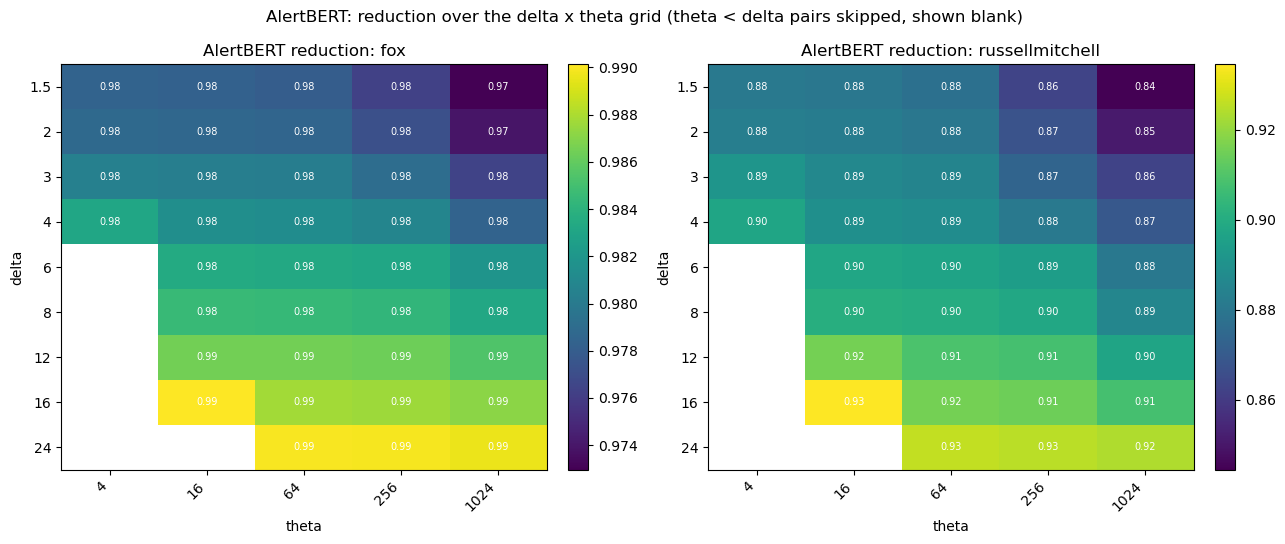

In [52]:
alertbert_df = results_dfs.get("alertbert")
if alertbert_df is None:
    print("[skip] alertbert not loaded -- run alertbert_sweep.py first")
else:
    # Diagnostic plot: reduction over the full delta x theta grid, one
    # heatmap per scenario -- a genuine 2-parameter sweep, so a heatmap
    # shows it more directly than a line plot would (contrast with the
    # CSCAS sensitivity sweep in 6b, which is deliberately one-at-a-time,
    # not a real 2D grid, so line plots were the right choice there instead).
    scenarios = sorted(alertbert_df["scenario"].unique())
    deltas = sorted(alertbert_df["delta"].unique())
    thetas = sorted(alertbert_df["theta"].unique())

    fig, axes = plt.subplots(1, len(scenarios), figsize=(6.5 * len(scenarios), 5.5), squeeze=False)
    for ax, scenario in zip(axes[0], scenarios):
        scen_df = alertbert_df[alertbert_df["scenario"] == scenario]
        pivot = scen_df.pivot(index="delta", columns="theta", values="reduction")
        pivot = pivot.reindex(index=deltas, columns=thetas)
        im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color="white")
        ax.set_xticks(range(len(thetas)))
        ax.set_xticklabels([f"{t:g}" for t in thetas], rotation=45, ha="right")
        ax.set_yticks(range(len(deltas)))
        ax.set_yticklabels([f"{d:g}" for d in deltas])
        ax.set_xlabel("theta")
        ax.set_ylabel("delta")
        ax.set_title(f"AlertBERT reduction: {scenario}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle("AlertBERT: reduction over the delta x theta grid (theta < delta pairs skipped, shown blank)")
    plt.tight_layout()
    plt.show()


In [53]:
# Every AlertBERT setting tested: the (delta, theta) pairs with
# theta >= delta (theta < delta is skipped upstream), both scenarios.
if alertbert_df is None:
    print("[skip] alertbert not loaded -- run alertbert_sweep.py first")
else:
    alertbert_settings_table = settings_table(
        alertbert_df,
        id_cols=["scenario", "delta", "theta"],
        sort_cols=["scenario", "delta", "theta"],
        title="AlertBERT -- every setting tested",
        latex_caption=(
            "AlertBERT grouping: every $(\\delta, \\theta)$ pair tested "
            "($\\theta \\geq \\delta$; smaller pairs skipped upstream), both "
            "held-out test scenarios."
        ),
        latex_label="tab:grouping-alertbert-settings",
        latex_longtable=True,
    )

AlertBERT -- every setting tested


reduction  group_size_mean  group_size_median  \
scenario        delta theta                                                   
fox             1.5   4.0        0.9784             46.4                3.0   
                      16.0       0.9783             46.1                3.0   
                      64.0       0.9780             45.5                3.0   
                      256.0      0.9763             42.2                3.0   
                      1024.0     0.9730             37.0                3.0   
                2.0   4.0        0.9789             47.3                3.0   
                      16.0       0.9787             47.0                3.0   
                      64.0       0.9786             46.7                3.0   
                      256.0      0.9772             43.8                3.0   
                      1024.0     0.9739             38.3                3.0   
                3.0   4.0        0.9804             51.1                3.0   
                      16.0       0.9803             50.8                3.0   
                      64.0       0.9802             50.6                3.0   
                      256.0      0.9791             47.9                3.0   
                      1024.0     0.9764             42.4                3.0   
                4.0   4.0        0.9831             59.3                3.0   
                      16.0       0.9815             53.9                3.0   
                      64.0       0.9813             53.5                3.0   
                      256.0      0.9808             52.1                3.0   
                      1024.0     0.9784             46.4                3.0   
                6.0   16.0       0.9834             60.4                3.0   
                      64.0       0.9833             59.9                3.0   
                      256.0      0.9831             59.2                3.0   
                      1024.0     0.9818             55.1                3.0   
                8.0   16.0       0.9846             64.7                3.0   
                      64.0       0.9845             64.3                3.0   
                      256.0      0.9843             63.6                3.0   
                      1024.0     0.9832             59.6                3.0   
                12.0  16.0       0.9865             74.1                3.0   
                      64.0       0.9865             74.0                3.0   
                      256.0      0.9863             73.1                3.0   
                      1024.0     0.9854             68.6                3.0   
                16.0  16.0       0.9901            101.4                6.0   
                      64.0       0.9878             81.8                6.0   
                      256.0      0.9876             80.7                6.0   
                      1024.0     0.9871             77.7                6.0   
                24.0  64.0       0.9900             99.9                6.0   
                      256.0      0.9899             99.0                6.0   
                      1024.0     0.9896             96.3                6.0   
russellmitchell 1.5   4.0        0.8810              8.4                3.0   
                      16.0       0.8800              8.3                3.0   
                      64.0       0.8778              8.2                3.0   
                      256.0      0.8631              7.3                3.0   
                      1024.0     0.8445              6.4                3.0   
                2.0   4.0        0.8831              8.6                3.0   
                      16.0       0.8821              8.5                3.0   
                      64.0       0.8803              8.4                3.0   
                      256.0      0.8674              7.5                3.0   
                      1024.0     0.8509              6.7                3.0   
 

\begin{longtable}{lllrrrrrrrrrrr}
\caption{AlertBERT grouping: every $(\delta, \theta)$ pair tested ($\theta \geq \delta$; smaller pairs skipped upstream), both held-out test scenarios.}\label{tab:grouping-alertbert-settings}\\
\toprule
Scenario & $\delta$ (s) & $\theta$ (s) & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endfirsthead
\multicolumn{14}{c}{\tablename\ \thetable\ (continued)}\\
\toprule
Scenario & $\delta$ (s) & $\theta$ (s) & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endhead
\midrule
\multicolumn{14}{r}{\emph{continued on next page}}\\
\endfoot
\bottomrule
\endlastfoot
fox & 1.5 & 4 & 0.978 & 46.4 & 3.0 & 821 & 274 & 1.38 & 15 & 91.40 & 86.31 & 13.68 & 0.01 \\
 &  & 16 & 0.978 & 46.1 & 3.0 & 821 & 274 & 1.37 & 15 & 91.90 & 

## 8. DeepCASE

Two-tier sweep (context length x DBSCAN eps) -- see `deepcase_sweep.py`'s module
docstring for the full sweep design, outlier convention, and runtime notes.


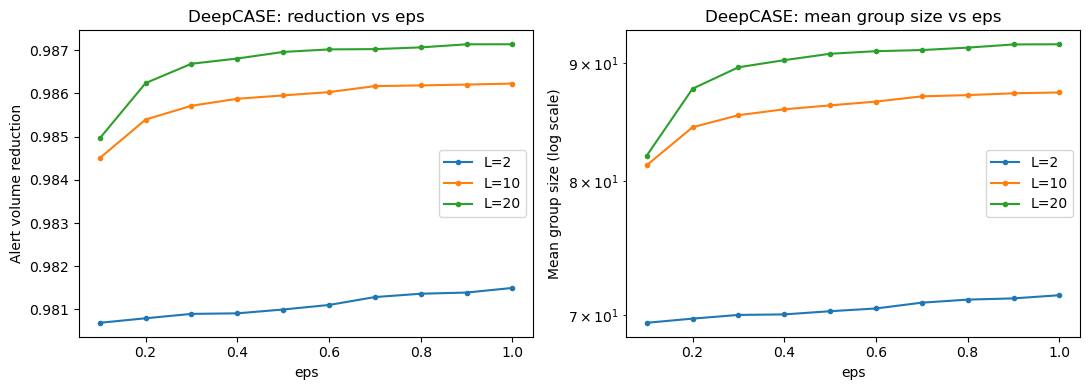

In [54]:
deepcase_df = results_dfs.get("deepcase")
if deepcase_df is None:
    print("[skip] deepcase not loaded -- run deepcase_sweep.py first")
else:
    # Per-method diagnostic plot: reduction and mean group size vs eps, one
    # line per context length L.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["reduction"].mean().sort_values("eps")
        ax[0].plot(agg["eps"], agg["reduction"], marker=".", label=f"L={L}")

    ax[0].set_xlabel("eps")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("DeepCASE: reduction vs eps")
    ax[0].legend()

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["group_size_mean"].mean().sort_values("eps")
        ax[1].plot(agg["eps"], agg["group_size_mean"], marker=".", label=f"L={L}")

    ax[1].set_yscale("log")
    ax[1].set_xlabel("eps")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("DeepCASE: mean group size vs eps")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


In [55]:
# Every DeepCASE setting tested: the context_length x eps grid (3 x 10 in
# a full GROUPING_RUN_FULL_DEEPCASE_SWEEP=1 run), both scenarios.
if deepcase_df is None:
    print("[skip] deepcase not loaded -- run deepcase_sweep.py first")
else:
    deepcase_settings_table = settings_table(
        deepcase_df,
        id_cols=["scenario", "context_length", "eps"],
        sort_cols=["scenario", "context_length", "eps"],
        title="DeepCASE -- every setting tested",
        latex_caption=(
            "DeepCASE grouping: the context-length $L$ $\\times$ "
            "DBSCAN-$\\varepsilon$ grid, both held-out test scenarios."
        ),
        latex_label="tab:grouping-deepcase-settings",
        latex_longtable=True,
    )

DeepCASE -- every setting tested


reduction  group_size_mean  \
scenario        context_length eps                               
fox             2              0.1     0.9904            104.5   
                               0.2     0.9905            104.8   
                               0.3     0.9905            105.1   
                               0.4     0.9905            105.2   
                               0.5     0.9905            105.4   
                               0.6     0.9905            105.6   
                               0.7     0.9906            106.0   
                               0.8     0.9906            106.2   
                               0.9     0.9906            106.4   
                               1.0     0.9906            106.6   
                10             0.1     0.9915            118.1   
                               0.2     0.9917            121.1   
                               0.3     0.9918            121.7   
                               0.4     0.9918            122.0   
                               0.5     0.9918            122.3   
                               0.6     0.9918            122.6   
                               0.7     0.9919            122.9   
                               0.8     0.9919            123.0   
                               0.9     0.9919            123.3   
                               1.0     0.9919            123.3   
                20             0.1     0.9915            117.7   
                               0.2     0.9919            124.0   
                               0.3     0.9920            125.6   
                               0.4     0.9921            126.3   
                               0.5     0.9921            126.6   
                               0.6     0.9921            126.8   
                               0.7     0.9921            127.0   
                               0.8     0.9921            127.2   
                               0.9     0.9921            127.4   
                               1.0     0.9922            127.4   
russellmitchell 2              0.1     0.9710             34.4   
                               0.2     0.9711             34.6   
                               0.3     0.9713             34.8   
                               0.4     0.9713             34.9   
                               0.5     0.9715             35.1   
                               0.6     0.9717             35.3   
                               0.7     0.9720             35.7   
                               0.8     0.9721             35.9   
                               0.9     0.9722             35.9   
                               1.0     0.9724             36.2   
                10             0.1     0.9775             44.4   
                               0.2     0.9791             47.7   
                               0.3     0.9796             49.1   
                               0.4     0.9800             49.9   
                               0.5     0.9801             50.2   
                               0.6     0.9802             50.5   
                               0.7     0.9805             51.2   
                               0.8     0.9805             51.3   
                               0.9     0.9805             51.3   
                               1.0     0.9806             51.5   
                20             0.1     0.9784             46.3   
                               0.2     0.9805             51.4   
                               0.3     0.9813             53.6   
                               0.4     0.9815             54.2   
                               0.5     0.9818             55.0   
                               0.6     0.9819             55.3   
                               0.7     0.9819             55.3   
                               0.8     0.9820             55.5   
                               0.9     0.9821             56.0   
          

\begin{longtable}{lllrrrrrrrrrrr}
\caption{DeepCASE grouping: the context-length $L$ $\times$ DBSCAN-$\varepsilon$ grid, both held-out test scenarios.}\label{tab:grouping-deepcase-settings}\\
\toprule
Scenario & $L$ & $\varepsilon$ & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endfirsthead
\multicolumn{14}{c}{\tablename\ \thetable\ (continued)}\\
\toprule
Scenario & $L$ & $\varepsilon$ & Reduction & Size mean & Size med. & Size max & Max/med. & Sig.\ div. & Sig.\ div.\ max & Host purity (\%) & Pure-benign (\%) & Pure-attack (\%) & Mixed (\%) \\
\midrule
\endhead
\midrule
\multicolumn{14}{r}{\emph{continued on next page}}\\
\endfoot
\bottomrule
\endlastfoot
fox & 2 & 0.1 & 0.990 & 104.5 & 1.0 & 377,349 & 377,349 & 1.00 & 5 & 98.80 & 35.73 & 63.61 & 0.66 \\
 &  & 0.2 & 0.991 & 104.8 & 1.0 & 377,604 & 377,604 & 1.00 & 5 & 98.80 & 35.50 & 63.84 & 0.66 \\
 &  & 0.3 &

### 8b. DeepCASE manual-review queue

Each outlier alert's `reason` (`"deepcase_low_confidence"` vs
`"deepcase_dbscan_noise"`) feeds `build_manual_review_records` (inside
`deepcase_sweep.py`), which turns the rejected alerts at each (scenario,
context_length)'s default eps into the actual queue those alerts would be
routed to for analyst review, mirroring DeepCASE's own semi-automatic mode
rather than just a conceptual description.


In [56]:
manual_review_df.to_csv("grouping_manual_review_queue.csv", index=False)
print(f"Manual review queue: {len(manual_review_df)} alerts")
if not manual_review_df.empty:
    print(manual_review_df["reason"].value_counts())


Manual review queue: 104428 alerts
reason
deepcase_low_confidence    102618
deepcase_dbscan_noise        1810
Name: count, dtype: int64


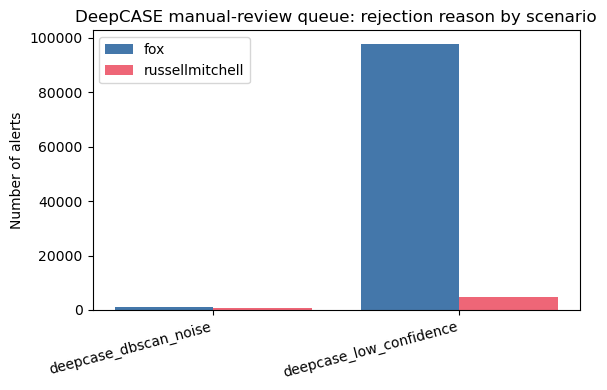

In [57]:
if manual_review_df.empty:
    print("[skip] no manual review rows loaded -- run deepcase_sweep.py first")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    reasons = sorted(manual_review_df["reason"].unique())
    scenarios = sorted(manual_review_df["scenario"].unique())
    x = np.arange(len(reasons))
    width = 0.8 / len(scenarios)

    for i, scenario in enumerate(scenarios):
        counts = (
            manual_review_df[manual_review_df["scenario"] == scenario]["reason"]
            .value_counts()
            .reindex(reasons, fill_value=0)
        )
        ax.bar(
            x + (i - (len(scenarios) - 1) / 2) * width, counts.values, width=width,
            label=scenario, color=SCENARIO_COLORS.get(scenario),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(reasons, rotation=15, ha="right")
    ax.set_ylabel("Number of alerts")
    ax.set_title("DeepCASE manual-review queue: rejection reason by scenario")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 9. Combined results and final comparison plots

Everything loaded above, combined into one DataFrame.

**Best-setting selection.** `best_settings` reduces each method to the one
swept configuration a deployment would actually run at: the highest *mean*
reduction across both scenarios, **restricted to configurations that clear
the section-2 selection guards on every scenario**. Unconstrained
reduction-argmax otherwise selects the degenerate operating points this
notebook's own plots (cells 35 / 37) warn about -- e.g. time-delta at
`delta` >> session length, where a whole scenario collapses into one group
(`reduction` -> 1.0, `mixed_frac` -> 1.0) -- and that setting would then
drive the entire section 10-11 scorecard.

The guards are tuned for the downstream miner (attribute **contrast**
mining): its cost is `O(n_groups)`, not group size -- each group becomes one
feature row -- so the guards cap **label noise** (`SELECT_MAX_MIXED_FRAC`),
**per-group feature-row blur** (`SELECT_MAX_SIGNATURE_DIVERSITY_MEAN`), and
enforce a **statistical-power floor** (`SELECT_MIN_N_GROUPS`).
`SELECT_MAX_GROUP_SIZE_MAX` is off by default and only relevant for an
itemset/tid-list miner (see cell 2).

One param per method (not two independent per-scenario argmaxes): a deployed
method runs at a single configuration, so this also lets Gate 3 (section
10.3) measure genuine cross-scenario transfer of the *same* operating point.
A method with **no** guard-clearing setting is reported at its raw
highest-reduction setting and flagged `selection_fallback` -- read that row
as "best achievable, guards notwithstanding", not as a deployable operating
point.


In [58]:
all_results_df.to_csv("grouping_comparison_results.csv", index=False)

if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    summary_table = None
else:
    # Structural finding, not a trivial case: DeepCASE is the only method in
    # this comparison with a rejection/deferral path, so it should be the
    # only method with a nonzero ungroupable_fraction -- worth asserting, not
    # just omitting as an obvious zero.
    non_deepcase_ungroupable = all_results_df.loc[
        all_results_df["method"] != "deepcase", "ungroupable_fraction"
    ]
    assert (non_deepcase_ungroupable == 0.0).all(), (
        "Expected ungroupable_fraction == 0.0 for every non-DeepCASE method "
        "(none of them have a rejection step)"
    )
    print(
        "Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method "
        "-- DeepCASE is the only method here with a rejection/deferral mode."
    )

    summary_table = all_results_df.groupby("method")[[
        "reduction", "coverage", "ungroupable_fraction", "group_size_mean", "n_groups",
        "pure_benign_frac", "pure_attack_frac", "mixed_frac",
        "host_purity", "signature_diversity_mean", "temporal_span_mean",
        "minority_label_exposure", "train_time_seconds", "inference_time_seconds",
    ]].mean()

summary_table


Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method -- DeepCASE is the only method here with a rejection/deferral mode.


,reduction,coverage,ungroupable_fraction,group_size_mean,n_groups,pure_benign_frac,pure_attack_frac,mixed_frac,host_purity,signature_diversity_mean,temporal_span_mean,minority_label_exposure,train_time_seconds,inference_time_seconds
method,,,,,,,,,,,,,,
alertbert,0.936865,1.000000,0.000000,35.059433,6669.064103,0.934032,0.065865,0.000104,0.873958,1.416130,1.590782,0.234241,NaN,15.790034
cscas_grouping,0.944114,1.000000,0.000000,43.879518,5298.500000,0.955665,0.043809,0.000526,1.000000,1.000000,20.269532,0.409420,NaN,0.542742
deepcase,0.984541,0.947268,0.052732,82.014233,2530.700000,0.542713,0.445367,0.011921,0.979115,1.004524,5346.191414,0.015594,175.425784,NaN
fixed_window,0.942503,1.000000,0.000000,40.906919,6204.583333,0.956497,0.043382,0.000121,0.811010,1.570445,4.215183,0.073810,NaN,0.186453
fixed_window_host,0.932446,1.000000,0.000000,31.081255,7360.166667,0.952113,0.047864,0.000023,1.000000,1.463302,2.188384,0.041667,NaN,0.213730
time_delta,0.959199,1.000000,0.000000,27390.133171,4452.940476,0.856638,0.036840,0.106522,0.611501,10.154303,40474.356323,0.128821,NaN,0.368702
time_delta_host,0.950781,1.000000,0.000000,324.320653,5393.357143,0.937412,0.049216,0.013371,1.000000,2.003711,2756.918284,0.151148,NaN,0.402716


In [59]:
# LaTeX -- section 9 cross-method summary. Needs \usepackage{booktabs} and
# \usepackage{graphicx} (for \resizebox). Metrics stay as columns, matching
# the DataFrame above; transpose in LaTeX if a tall layout reads better.
if summary_table is not None and not summary_table.empty:
    print(to_latex_table(
        summary_table.rename_axis("method"),
        caption=(
            "Cross-method comparison: each method's mean over all swept "
            "settings and both held-out test scenarios "
            "(\\texttt{fox}, \\texttt{russellmitchell})."
        ),
        label="tab:grouping-summary",
        resizebox=True,
    ))

\begin{table}[htbp]
\centering
\small
\caption{Cross-method comparison: each method's mean over all swept settings and both held-out test scenarios (\texttt{fox}, \texttt{russellmitchell}).}
\label{tab:grouping-summary}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
Method & Reduction & Coverage & Ungroupable & Size mean & \#groups & Pure-benign & Pure-attack & Mixed & Host purity & Sig.\ div. & Span (s) & Minority exp. & Train (s) & Infer (s) \\
\midrule
alertbert & 0.937 & 1.000 & 0.000 & 35.1 & 6,669 & 0.934 & 0.066 & 0.000 & 0.874 & 1.42 & 1.6 & 0.234 & -- & 15.79 \\
cscas\_grouping & 0.944 & 1.000 & 0.000 & 43.9 & 5,298 & 0.956 & 0.044 & 0.001 & 1.000 & 1.00 & 20.3 & 0.409 & -- & 0.54 \\
deepcase & 0.985 & 0.947 & 0.053 & 82.0 & 2,531 & 0.543 & 0.445 & 0.012 & 0.979 & 1.00 & 5,346.2 & 0.016 & 175.4 & -- \\
fixed\_window & 0.943 & 1.000 & 0.000 & 40.9 & 6,205 & 0.956 & 0.043 & 0.000 & 0.811 & 1.57 & 4.2 & 0.074 & -- & 0.19 \\
fixed\_window\_host & 0.932 & 1.0

In [60]:
if all_results_df.empty:
    best_settings = pd.DataFrame()
    best_param_per_method = pd.DataFrame()
else:
    # ------------------------------------------------------------------
    # Jointly-best setting per method: the single swept configuration a
    # deployment would run at -- highest MEAN reduction across both
    # scenarios, but only among configurations that also clear the
    # section-2 selection guards on EVERY scenario (see the section 9
    # markdown, and cell 2 for why each guard is shaped the way it is for
    # contrast mining). One param per method, not two independent
    # per-scenario argmaxes, so Gate 3 (section 10.3) compares the SAME
    # operating point across scenarios.
    # ------------------------------------------------------------------
    # (column, direction, threshold) -- threshold None disables that guard.
    _GUARD_SPECS = [
        ("mixed_frac", "max", SELECT_MAX_MIXED_FRAC),
        ("signature_diversity_mean", "max", SELECT_MAX_SIGNATURE_DIVERSITY_MEAN),
        ("n_groups", "min", SELECT_MIN_N_GROUPS),
        ("group_size_max", "max", SELECT_MAX_GROUP_SIZE_MAX),
    ]
    _active_guards = [g for g in _GUARD_SPECS if g[2] is not None]

    _guard_row = pd.Series(True, index=all_results_df.index)
    for _col, _direction, _thr in _active_guards:
        _guard_row &= (
            all_results_df[_col] >= _thr
            if _direction == "min"
            else all_results_df[_col] <= _thr
        )

    # per (method, param): mean reduction, whether every scenario passed,
    # and the worst value seen for each guarded column (max for a ceiling
    # guard, min for a floor guard) so a failure is explainable.
    _worst_agg = {
        f"worst_{col}": (col, "min" if direction == "min" else "max")
        for col, direction, _ in _GUARD_SPECS
    }
    _by_param = (
        all_results_df.assign(_ok=_guard_row)
        .groupby(["method", "param"], as_index=False)
        .agg(reduction=("reduction", "mean"), admissible=("_ok", "all"),
             n_scenarios=("_ok", "size"), **_worst_agg)
    )

    _admissible = _by_param[_by_param["admissible"]]
    _admissible_methods = set(_admissible["method"])
    # Per method: choose within its admissible settings; a method with none
    # falls back to its own raw highest-reduction setting (flagged below).
    _pool = _by_param[
        _by_param["admissible"] | ~_by_param["method"].isin(_admissible_methods)
    ]
    best_param_per_method = (
        # `param` as a secondary key only so ties (e.g. every sub-timestamp-
        # resolution time-delta setting scores identically) resolve
        # deterministically across runs.
        _pool.sort_values(["reduction", "param"], ascending=[False, True])
        .groupby("method", as_index=False)
        .first()[["method", "param", "reduction"]]
    )
    best_param_per_method["selection_fallback"] = ~best_param_per_method["method"].isin(
        _admissible_methods
    )

    best_settings = all_results_df.merge(
        best_param_per_method[["method", "param", "selection_fallback"]],
        on=["method", "param"],
    )

    # ---- diagnostic: what each method got, and why -------------------
    _n_total = _by_param.groupby("method").size()
    _n_adm = _by_param[_by_param["admissible"]].groupby("method").size()
    _guard_str = ", ".join(
        f"{col} {'>=' if d == 'min' else '<='} {thr:,}" if isinstance(thr, int)
        else f"{col} {'>=' if d == 'min' else '<='} {thr}"
        for col, d, thr in _active_guards
    )
    print(f"Best-setting selection -- guards: {_guard_str}")
    for _, r in best_param_per_method.sort_values("method").iterrows():
        _tag = "   [FALLBACK -- no admissible setting]" if r["selection_fallback"] else ""
        print(
            f"  {r['method']:18s} {r['param']!r:26s} "
            f"mean_reduction={r['reduction']:.4f}  "
            f"admissible={int(_n_adm.get(r['method'], 0))}/{int(_n_total.get(r['method'], 0))}{_tag}"
        )

    _fallback = best_param_per_method[best_param_per_method["selection_fallback"]]
    if not _fallback.empty:
        _worst_cols = [f"worst_{col}" for col, _, _ in _active_guards]
        print(
            "\nNOTE: no swept setting clears every guard on every scenario for "
            "the method(s) below -- the row is the raw highest-reduction "
            "setting, with the worst guarded value it hit:"
        )
        print(
            _by_param.merge(_fallback[["method", "param"]], on=["method", "param"])[
                ["method", "param", "reduction", *_worst_cols]
            ].to_string(index=False)
        )

    # Sanity check, within the admissible pool: is the joint param also each
    # scenario's own best admissible param? A mismatch means the method's
    # scenarios pull toward different operating points -- surfaced, not
    # silently averaged. (Fallback methods have no admissible pool to
    # compare within, so they are skipped.)
    _row_ok = all_results_df[_guard_row]
    if not _row_ok.empty:
        _indep = (
            _row_ok.sort_values(["reduction", "param"], ascending=[False, True])
            .groupby(["method", "scenario"], as_index=False)
            .first()[["method", "scenario", "param"]]
        )
        _joint = best_param_per_method.set_index("method")["param"]
        _indep["diverges"] = _indep.apply(
            lambda r: r["param"] != _joint.get(r["method"]), axis=1
        )
        _div = _indep[_indep["diverges"] & _indep["method"].isin(_admissible_methods)]
        if _div.empty:
            print(
                "\nConfirmed: for every non-fallback method the joint "
                "admissible param is also each scenario's own best admissible "
                "param -- no method's scenarios pull toward different "
                "operating points."
            )
        else:
            print(
                "\nNOTE: joint vs. per-scenario best admissible param diverges "
                "for the (method, scenario) pairs below -- that method's "
                "reduction on this scenario is not its own per-scenario "
                "ceiling:\n"
                + _div.drop(columns="diverges").to_string(index=False)
            )

best_settings.head()


Best-setting selection -- guards: mixed_frac <= 0.02, signature_diversity_mean <= 2.5, n_groups >= 200
  alertbert          'd=16.0000_t=16.0000'      mean_reduction=0.9623  admissible=39/39
  cscas_grouping     'len=300_timeout=60'       mean_reduction=0.9441  admissible=1/1
  deepcase           'L=20_eps=1.0'             mean_reduction=0.9871  admissible=26/30
  fixed_window       '60'                       mean_reduction=0.9706  admissible=6/6
  fixed_window_host  '60'                       mean_reduction=0.9540  admissible=6/6
  time_delta         '32.0000'                  mean_reduction=0.9765  admissible=25/42
  time_delta_host    '512.0000'                 mean_reduction=0.9909  admissible=33/42

NOTE: joint vs. per-scenario best admissible param diverges for the (method, scenario) pairs below -- that method's reduction on this scenario is not its own per-scenario ceiling:
         method        scenario        param
       deepcase russellmitchell L=20_eps=0.9
     time_delta 

,method,param,n_raw_alerts,reduction,coverage,ungroupable_fraction,group_size_mean,group_size_median,group_size_max,n_groups,...,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario,delta,theta,context_length,eps,selection_fallback
0,fixed_window,60,473104,0.992435,1.0,0.0,132.188880,9.0,22117,3579,...,19.684269,17.0,59.0,0.142857,fox,NaN,NaN,NaN,NaN,False
1,fixed_window_host,60,473104,0.987197,1.0,0.0,78.108635,6.0,22117,6057,...,9.764735,0.0,59.0,0.000000,fox,NaN,NaN,NaN,NaN,False
2,fixed_window,60,45544,0.948753,1.0,0.0,19.513282,8.0,5961,2334,...,16.395030,10.0,59.0,0.266667,russellmitchell,NaN,NaN,NaN,NaN,False
3,fixed_window_host,60,45544,0.920758,1.0,0.0,12.619562,6.0,5953,3609,...,8.477972,0.0,59.0,0.500000,russellmitchell,NaN,NaN,NaN,NaN,False
4,time_delta,32.0000,473104,0.994703,1.0,0.0,188.788508,9.0,420429,2506,...,32.746209,11.0,1423.0,0.282609,fox,32.0,NaN,NaN,NaN,False


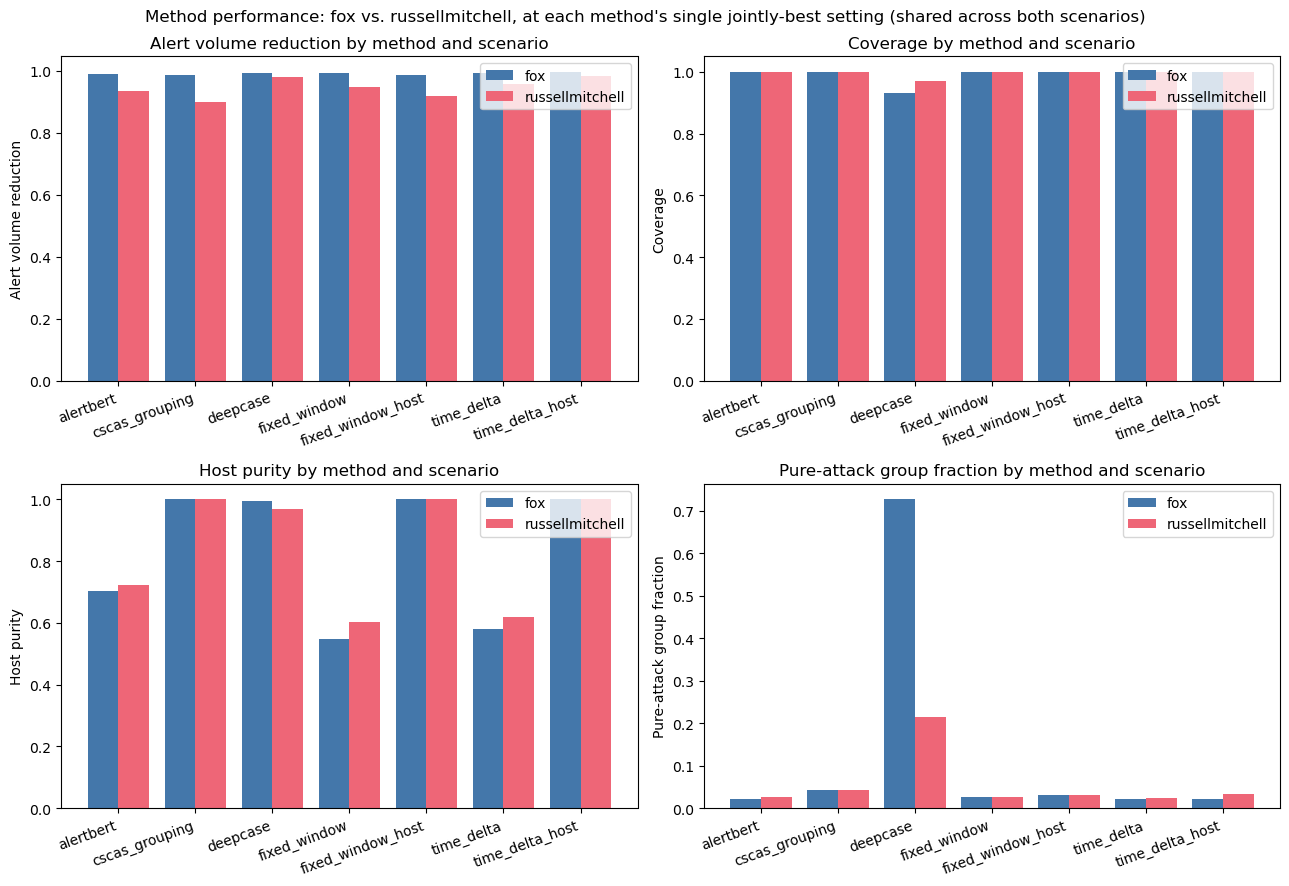

In [61]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Headline comparison: does each method perform consistently across
    # both test scenarios, or does it diverge? One panel per metric, each a
    # grouped bar chart (method on x-axis, one bar per scenario) built from
    # each method's single jointly-best setting (chosen in section 9 to
    # maximize mean reduction across both scenarios), evaluated on each
    # scenario in turn -- not two independently-tuned settings.
    metrics = [
        ("reduction", "Alert volume reduction"),
        ("coverage", "Coverage"),
        ("host_purity", "Host purity"),
        ("pure_attack_frac", "Pure-attack group fraction"),
    ]
    methods = sorted(best_settings["method"].unique())
    scenarios = sorted(best_settings["scenario"].unique())
    x = np.arange(len(methods))
    width = 0.8 / len(scenarios)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (col, title) in zip(axes.flat, metrics):
        for i, scenario in enumerate(scenarios):
            scen_df = best_settings[best_settings["scenario"] == scenario].set_index("method")
            values = [scen_df[col].get(m, 0.0) for m in methods]
            ax.bar(
                x + (i - (len(scenarios) - 1) / 2) * width, values, width=width,
                label=scenario, color=SCENARIO_COLORS.get(scenario),
            )
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=20, ha="right")
        ax.set_ylabel(title)
        ax.set_title(f"{title} by method and scenario")
        ax.legend()

    fig.suptitle("Method performance: fox vs. russellmitchell, at each method's single jointly-best setting (shared across both scenarios)")
    plt.tight_layout()
    plt.show()


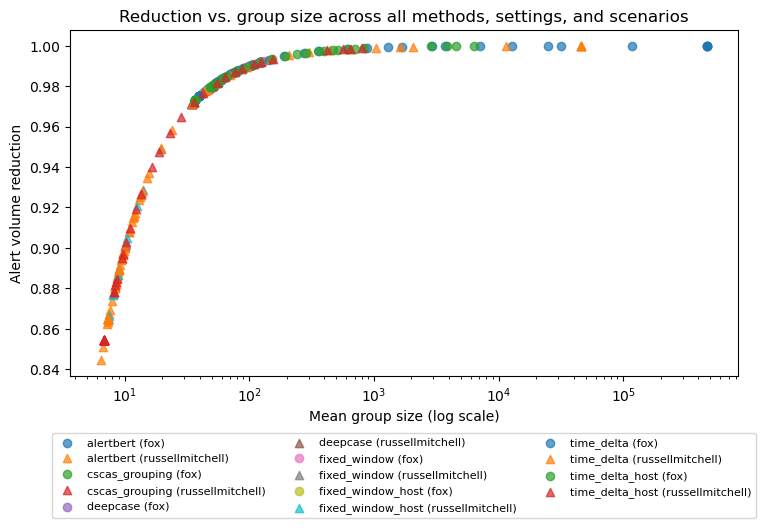

In [62]:
if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 1: reduction vs mean group size, all methods overlaid,
    # split by scenario (marker shape) so a method that performs very
    # differently on fox vs russellmitchell doesn't get silently averaged
    # away. This is the key tradeoff plot -- high reduction from one giant
    # group is not the same achievement as high reduction from many
    # well-formed groups.
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for (method_name, scenario), group in all_results_df.groupby(["method", "scenario"]):
        agg = group.groupby("param", as_index=False)[["reduction", "group_size_mean"]].mean()
        ax.scatter(
            agg["group_size_mean"], agg["reduction"],
            label=f"{method_name} ({scenario})",
            marker=SCENARIO_MARKERS.get(scenario, "o"),
            alpha=0.7,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Mean group size (log scale)")
    ax.set_ylabel("Alert volume reduction")
    ax.set_title("Reduction vs. group size across all methods, settings, and scenarios")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


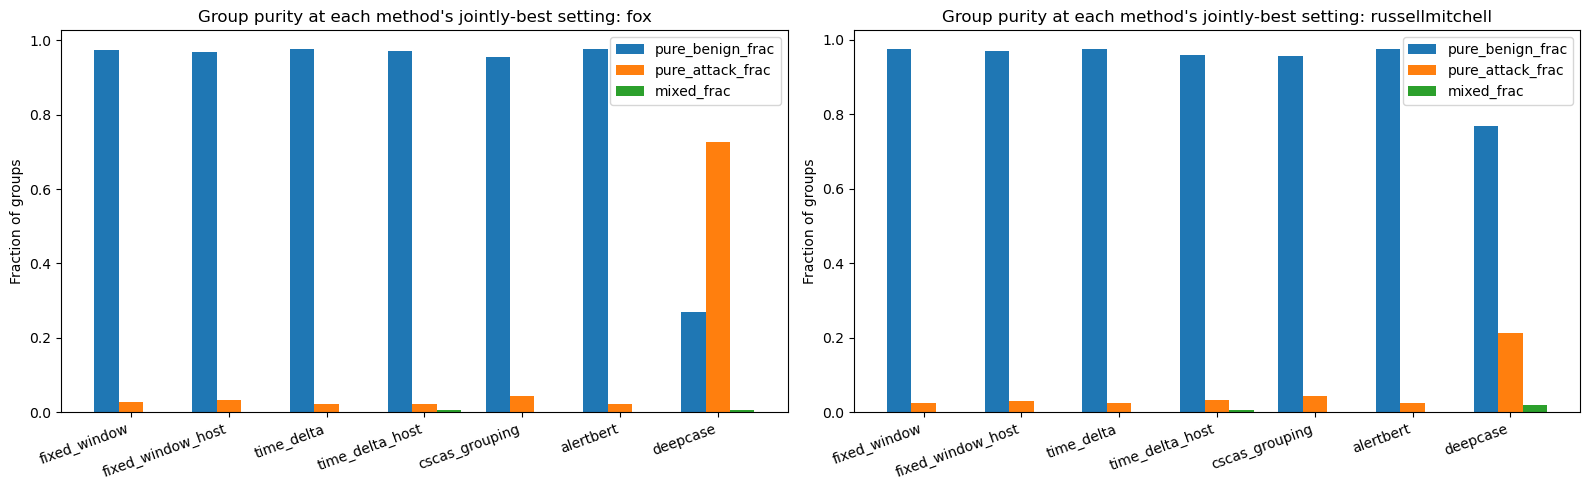

In [63]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 2: purity comparison at each method's jointly-best
    # setting (section 9), faceted by scenario (not pooled) -- one
    # subplot per scenario so no method's bar silently reflects a
    # different scenario than another method's.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(8 * len(scenarios), 5), squeeze=False)

    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        x = np.arange(len(scen_settings))
        width = 0.25

        for i, col in enumerate(["pure_benign_frac", "pure_attack_frac", "mixed_frac"]):
            ax.bar(x + i * width, scen_settings[col], width=width, label=col)

        ax.set_xticks(x + width)
        ax.set_xticklabels(scen_settings["method"], rotation=20, ha="right")
        ax.set_ylabel("Fraction of groups")
        ax.set_title(f"Group purity at each method's jointly-best setting: {scenario}")
        ax.legend()

    plt.tight_layout()
    plt.show()


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3598010401.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3598010401.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)


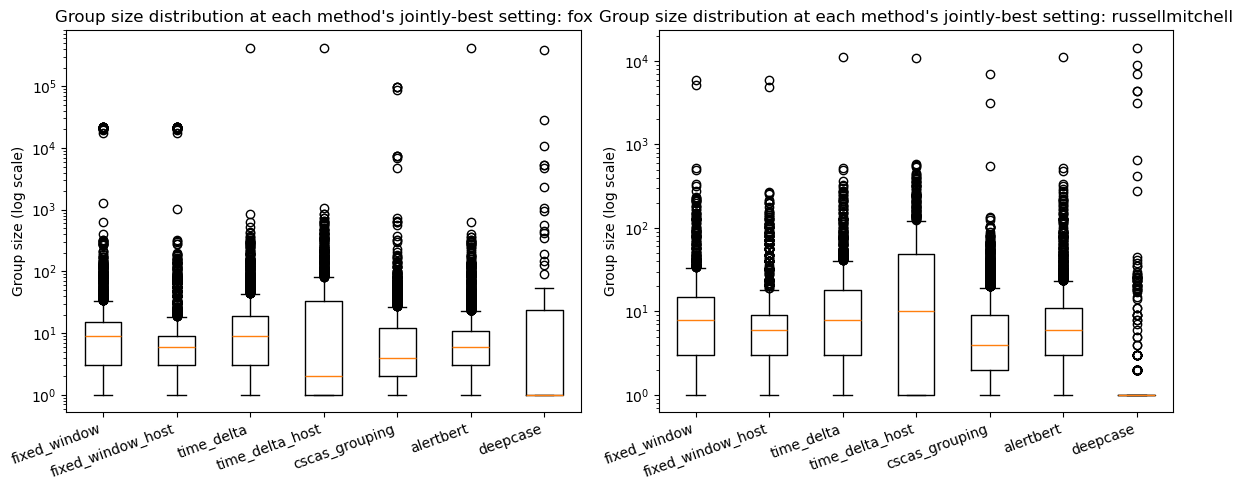

In [64]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 3: group size distributions (log-y boxplot) at each
    # method's jointly-best setting (section 9), faceted by scenario --
    # surfaces the runaway-group pathology (long streams of dense,
    # repetitive alerts collapsing into a single giant group) that flat
    # mean/median stats can hide. Needs the raw per-setting arrays from
    # *_sizes.npz, not just the mean/median/max already in all_results_df.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5), squeeze=False)

    any_data = False
    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        box_data = []
        labels = []
        for _, row in scen_settings.iterrows():
            key = (row["method"], row["param"], row["scenario"])
            if key in size_arrays:
                box_data.append(size_arrays[key])
                labels.append(row["method"])

        if box_data:
            any_data = True
            ax.boxplot(box_data, labels=labels, showfliers=True)
            ax.set_yscale("log")
            ax.set_ylabel("Group size (log scale)")
            ax.set_title(f"Group size distribution at each method's jointly-best setting: {scenario}")
            ax.set_xticklabels(labels, rotation=20, ha="right")
        else:
            ax.set_title(f"{scenario}: no group-size arrays loaded")

    plt.tight_layout()
    if any_data:
        plt.show()
    else:
        print("[skip] no group-size arrays loaded for any best setting")


## 10. Integration screening

The comparison above (section 9) treats all five methods symmetrically. This
section reframes the same underlying results around a different question:
**which of these methods are viable drop-in grouping components for the
system being designed, not just which one scores highest overall.**

For each requirement below, a leaderboard ranks *all five methods* against a
threshold line -- nothing is dropped yet, so every method's full profile is
visible before any elimination happens. Section 11 then combines all
requirements into a single scorecard and applies them together to see which
methods actually survive.


In [65]:
# --- Integration thresholds (sections 10-11 gates) -------------------------
# TODO: replace with the target system's actual requirements before the
# write-up -- these are illustrative, NOT tuned for or against any method.
#
# Gate 2 is shaped for the downstream miner = attribute CONTRAST mining
# (see cell 2). That miner assigns each group a single label and contrasts
# the attack vs. benign feature distributions, so what it needs from
# grouping is:
#   (2a) trustworthy labels   -> few MIXED groups
#   (2b) attacks not buried    -> low minority-label exposure inside the
#                                 mixed groups that do exist
#   (2c) enough attack signal  -> an absolute floor on pure-attack groups
# It does NOT need pure-attack groups to *dominate* -- a mostly-benign but
# cleanly single-label grouping is fine -- so there is no
# "pure_attack_frac >= 0.5" bar (that would punish a method for correctly
# isolating benign traffic).
MIN_REDUCTION = 0.5                  # Gate 1: min acceptable alert-volume reduction
MAX_MIXED_FRAC = 0.02               # Gate 2a: max fraction of mixed (multi-label) groups
MAX_MINORITY_LABEL_EXPOSURE = 0.15   # Gate 2b: max minority-label fraction within mixed groups
MIN_MIXED_FRAC_FOR_EXPOSURE = 0.01   # Gate 2b only bites above this mixed_frac -- below it,
                                     #   minority_label_exposure is a few-alert ratio, not a real leak
MIN_PURE_ATTACK_GROUPS = 50          # Gate 2c: min pure-attack groups (absolute, worst scenario)
MAX_SCENARIO_GAP = 0.15              # Gate 3: max |reduction_fox - reduction_russellmitchell|
REQUIRES_NO_REJECTION = False        # Gate 4: must every alert be grouped (no deferral path)?

GATE_PASS_COLOR = "#4CAF50"
GATE_FAIL_COLOR = "#E15759"


### 10.0 The compression tradeoff

Every method's full sweep, plotted against **alert volume reduction**
(compression -- the knob). Four panels, each one axis of "does
compression cost you mining-usable groups": pure-benign group count,
pure-attack group count, label cleanliness (mixed-group fraction), and
coherence (mean signatures per group). A star marks each method's
**median** value on that panel's metric (the setting closest to the
method's own median, independently per panel -- not a single shared
"selected setting"; these are sweeps over a knob, not a pick of one
config). All four collapse together as `time_delta`/`time_delta_host`
push reduction toward 1.0 -- the same runaway-group mechanism discussed
in sections 4b/5.

Each point is one (method, setting), averaged across the two scenarios --
x is mean reduction, y is the mean of the panel's metric. CSCAS is not
swept in production, but its 5-point sensitivity check (section 6) is
folded in here so it gets a short curve like every other method, rather
than a single bare point. The label-cleanliness panel uses a symlog
y-axis (linear near zero, log beyond $10^{-4}$): mixed-group fraction is
genuinely zero for many settings, which a plain log axis cannot display,
but plain linear compresses everything except the `time_delta` collapse
into an indistinguishable smear near zero.

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3432573562.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  _tr_src = pd.concat([all_results_df, cscas_sensitivity_df], ignore_index=True)


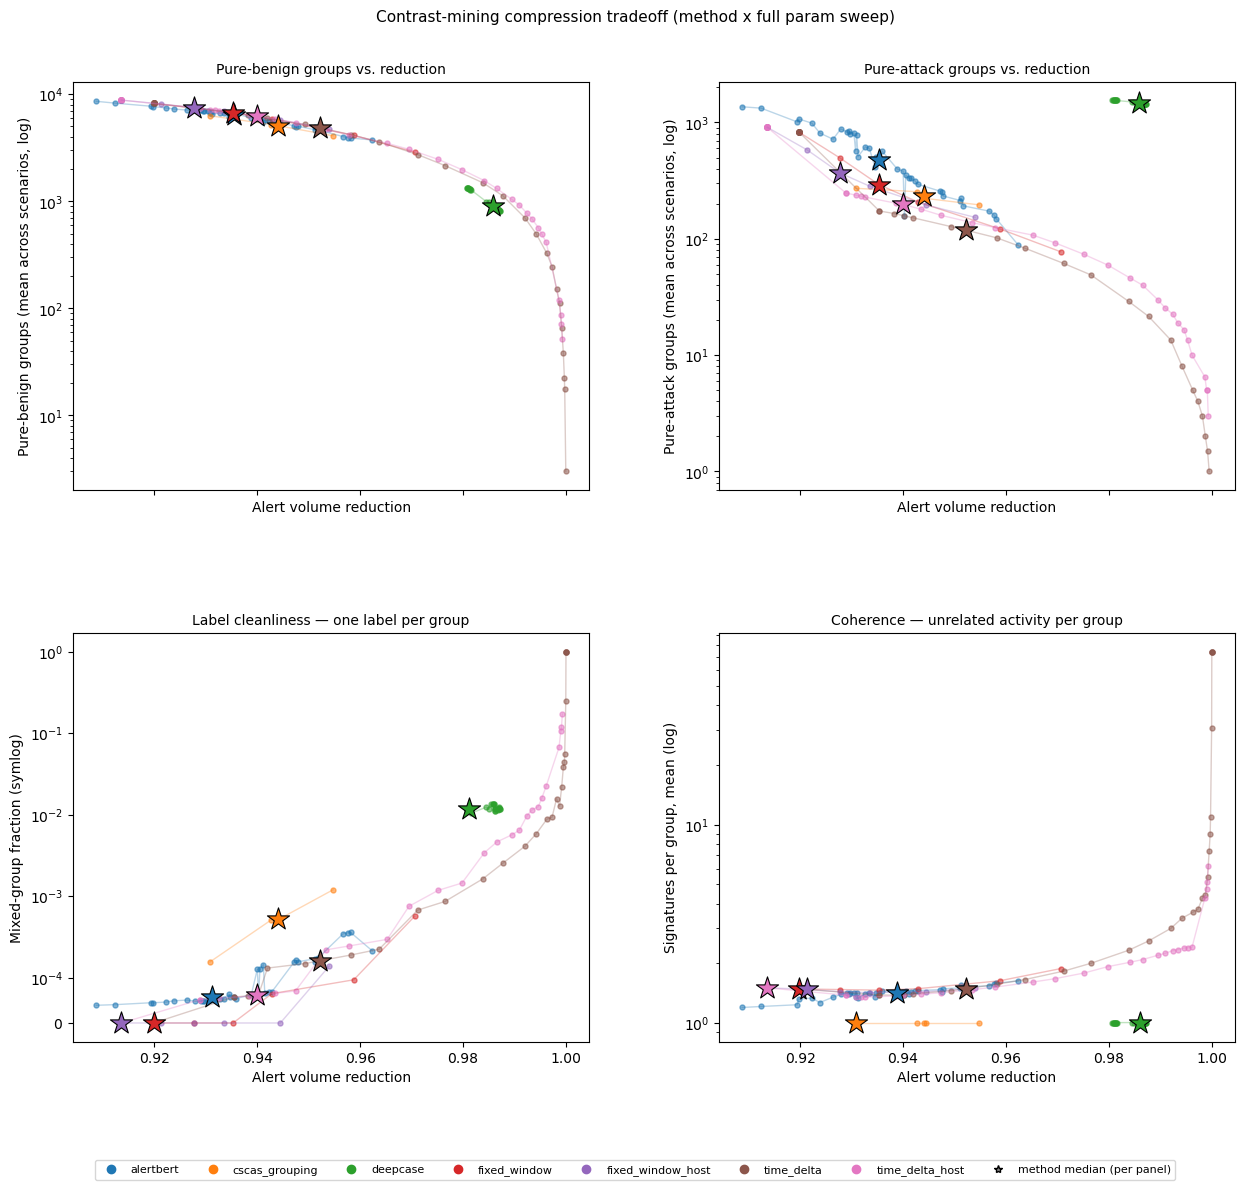

,n_pure_benign,n_pure_attack,mixed_frac,signature_diversity_mean
method,,,,
alertbert,6430.0,476.0,0.0001,1.42
cscas_grouping,5064.0,232.0,0.0005,1.00
deepcase,897.0,1474.0,0.0117,1.00
fixed_window,6282.0,250.0,0.0000,1.49
fixed_window_host,7195.0,326.0,0.0000,1.46
time_delta,4522.0,110.0,0.0002,1.53
time_delta_host,6041.0,189.0,0.0001,1.50


In [66]:
if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # CSCAS is not swept -- all_results_df only carries its single primary
    # setting (300s/60s). Fold in the 5-point sensitivity sweep here too,
    # purely so CSCAS gets a short curve like every other method instead of
    # one bare star; those 5 settings are a robustness check on the
    # published config, not real deployment alternatives (section 6).
    _tr_src = pd.concat([all_results_df, cscas_sensitivity_df], ignore_index=True)
    _tr_src = _tr_src.drop_duplicates(subset=["method", "param", "scenario"])
    _tr = _tr_src.assign(
        n_pure_attack=lambda d: (d["pure_attack_frac"] * d["n_groups"]).round(),
        n_pure_benign=lambda d: (d["pure_benign_frac"] * d["n_groups"]).round(),
    )
    _curve = _tr.groupby(["method", "param"], as_index=False).agg(
        reduction=("reduction", "mean"),
        n_pure_benign=("n_pure_benign", "mean"),
        n_pure_attack=("n_pure_attack", "mean"),
        mixed_frac=("mixed_frac", "mean"),
        signature_diversity_mean=("signature_diversity_mean", "mean"),
    )

    # col, y-label, subtitle, logy, symlogy
    _panels = [
        ("n_pure_benign", "Pure-benign groups (mean across scenarios, log)",
         "Pure-benign groups vs. reduction", True, False),
        ("n_pure_attack", "Pure-attack groups (mean across scenarios, log)",
         "Pure-attack groups vs. reduction", True, False),
        ("mixed_frac", "Mixed-group fraction (symlog)",
         "Label cleanliness \u2014 one label per group", False, True),
        ("signature_diversity_mean", "Signatures per group, mean (log)",
         "Coherence \u2014 unrelated activity per group", True, False),
    ]

    _methods = sorted(_curve["method"].unique())
    _cmap = plt.get_cmap("tab10")
    _color = {m: _cmap(i % 10) for i, m in enumerate(_methods)}

    fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True)
    for ax, (col, ylab, subtitle, logy, symlogy) in zip(axes.flat, _panels):
        for m in _methods:
            g = _curve[_curve["method"] == m].sort_values("reduction")
            yv = g[col].where(g[col] > 0) if logy else g[col]
            ax.plot(g["reduction"], yv, "-", color=_color[m], alpha=0.3, linewidth=1)
            ax.scatter(g["reduction"], yv, s=13, color=_color[m], alpha=0.55)
            # star = the setting whose value on THIS panel's metric is
            # closest to this method's own median -- independent per panel,
            # not a single shared "selected setting".
            _median_val = g[col].median()
            _median_idx = (g[col] - _median_val).abs().idxmin()
            _median_row = g.loc[[_median_idx]]
            yv_med = _median_row[col].where(_median_row[col] > 0) if logy else _median_row[col]
            ax.scatter(_median_row["reduction"], yv_med, marker="*", s=280,
                       color=_color[m], edgecolor="black", linewidth=0.8, zorder=6)
        if logy:
            ax.set_yscale("log")
        if symlogy:
            ax.set_yscale("symlog", linthresh=1e-4, linscale=0.5)
        ax.set_ylabel(ylab)
        ax.set_title(subtitle, fontsize=10)
        ax.set_xlabel("Alert volume reduction")

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=_color[m], label=m)
        for m in _methods
    ]
    handles.append(plt.Line2D([0], [0], marker="*", linestyle="", color="grey",
                              markeredgecolor="black", label="method median (per panel)"))
    fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.35, wspace=0.25)
    fig.legend(handles=handles, loc="lower center", ncol=len(_methods) + 1,
               fontsize=8, bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(
        "Contrast-mining compression tradeoff (method x full param sweep)",
        fontsize=11,
    )
    plt.show()

    # Numeric backing for the stars: each method's median value on every
    # panel's metric (independently per column, not tied to one setting).
    _medians = _curve.groupby("method")[
        ["n_pure_benign", "n_pure_attack", "mixed_frac", "signature_diversity_mean"]
    ].median().round({"n_pure_benign": 0, "n_pure_attack": 0,
                       "mixed_frac": 4, "signature_diversity_mean": 2})
    display(_medians)


### 10.1 Gate 1 -- Alert volume reduction (and mining cost)

Baseline requirement: is the method reducing volume enough to be worth
integrating at all? Ranked on each method's single jointly-best setting
(section 9), mean across scenarios.

`gate1_df` also carries `n_groups` -- the matching **cost** side. Contrast
mining does one feature-row pass per group, so mining work scales with the
group *count*, not group size: a method that reduces less leaves more rows
to mine. Reduction is the benefit, `n_groups` the price.


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/2021010410.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gate1_df["method"], rotation=20, ha="right")


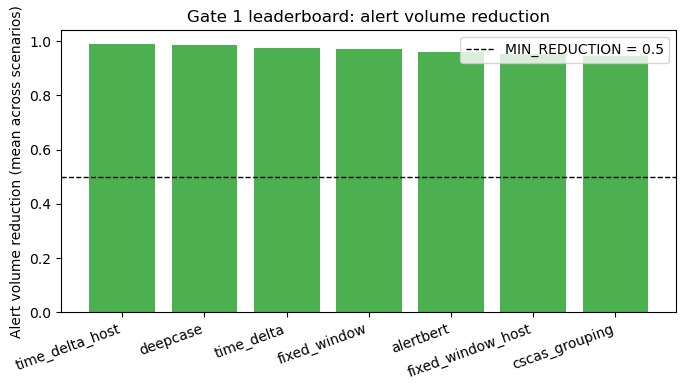

,method,reduction,n_groups
0,time_delta_host,0.990919,954.0
1,deepcase,0.987140,2263.5
2,time_delta,0.976482,2203.5
3,fixed_window,0.970594,2956.5
4,alertbert,0.962329,3825.0
5,fixed_window_host,0.953978,4833.0
6,cscas_grouping,0.944114,5298.5


In [67]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate1_df = pd.DataFrame()
else:
    # Volume gate: reduction (benefit) + n_groups (contrast-mining cost --
    # one feature row per group), both mean across scenarios at the
    # jointly-best setting.
    gate1_df = (
        best_settings.groupby("method", as_index=False)
        .agg(reduction=("reduction", "mean"), n_groups=("n_groups", "mean"))
        .sort_values("reduction", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = [
        GATE_PASS_COLOR if v >= MIN_REDUCTION else GATE_FAIL_COLOR
        for v in gate1_df["reduction"]
    ]
    ax.bar(gate1_df["method"], gate1_df["reduction"], color=colors)
    ax.axhline(MIN_REDUCTION, color="black", linestyle="--", linewidth=1,
               label=f"MIN_REDUCTION = {MIN_REDUCTION:g}")
    ax.set_ylabel("Alert volume reduction (mean across scenarios)")
    ax.set_title("Gate 1 leaderboard: alert volume reduction")
    ax.set_xticklabels(gate1_df["method"], rotation=20, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

gate1_df


### 10.2 Gate 2 -- Downstream signal preservation

Does grouping keep the alert stream usable for contrast mining, or does it
destroy the label signal the miner contrasts on? Three sub-checks (cell 39),
because they can disagree:

| check | metric | direction | why |
|---|---|---|---|
| 2a | `mixed_frac` | lower | each group gets ONE label; a mixed group feeds the wrong class's features into the contrast stats |
| 2b | `minority_label_exposure` | lower | of the alerts in mixed groups, the fraction that are the minority label -- what a consumer reading only the majority label misses. **Only checked when `mixed_frac > MIN_MIXED_FRAC_FOR_EXPOSURE`** -- below that it is a ratio over a handful of alerts, not a real leak. |
| 2c | `n_pure_attack_groups` | higher | absolute count of pure-attack groups at the **worst** scenario (`pure_attack_frac x n_groups`, min over scenarios) -- contrast mining needs enough attack rows for growth-rate / chi-square to mean anything |

Deliberately **no** "pure-attack groups must dominate" check -- a clean,
mostly-benign grouping is fine for contrast mining as long as its labels
are trustworthy (2a) and enough attack groups exist (2c).


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3311555122.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(sub["method"], rotation=20, ha="right")
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3311555122.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sub["method"], rotation=20, ha="right")
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/3311555122.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(sub["method"], rotation=20, ha="right")


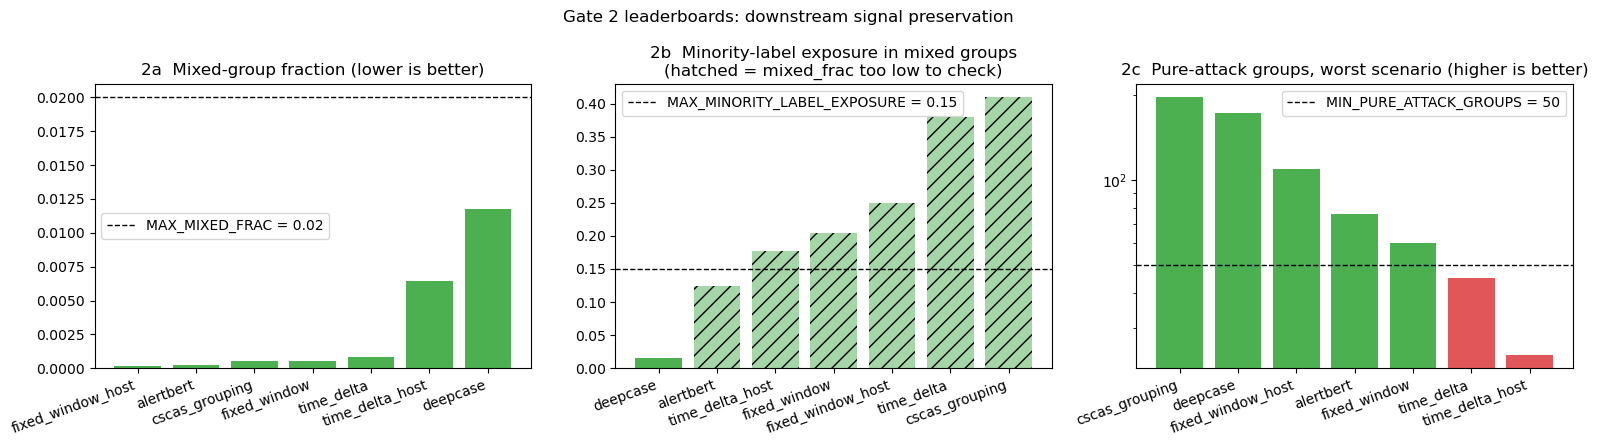

,method,mixed_frac,minority_label_exposure,pure_attack_frac,n_pure_attack_groups
0,alertbert,0.000214,0.125000,0.023669,76.0
1,cscas_grouping,0.000526,0.409420,0.043809,198.0
2,deepcase,0.011772,0.015460,0.470198,174.0
3,fixed_window,0.000568,0.204762,0.026125,60.0
4,fixed_window_host,0.000139,0.250000,0.031419,110.0
5,time_delta,0.000862,0.380260,0.022410,45.0
6,time_delta_host,0.006438,0.177755,0.028142,24.0


In [68]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate2_df = pd.DataFrame()
else:
    # n_pure_attack_groups: pure_attack_frac x n_groups per scenario, then
    # the MIN across scenarios -- the worst-case attack signal the miner
    # would actually get, not a scenario-averaged one.
    _g2 = best_settings.assign(
        n_pure_attack_groups=lambda d: (d["pure_attack_frac"] * d["n_groups"]).round()
    )
    gate2_df = _g2.groupby("method", as_index=False).agg(
        mixed_frac=("mixed_frac", "mean"),
        minority_label_exposure=("minority_label_exposure", "mean"),
        pure_attack_frac=("pure_attack_frac", "mean"),
        n_pure_attack_groups=("n_pure_attack_groups", "min"),
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    sub = gate2_df.sort_values("mixed_frac")
    colors = [GATE_PASS_COLOR if v <= MAX_MIXED_FRAC else GATE_FAIL_COLOR for v in sub["mixed_frac"]]
    axes[0].bar(sub["method"], sub["mixed_frac"], color=colors)
    axes[0].axhline(MAX_MIXED_FRAC, color="black", linestyle="--", linewidth=1,
                     label=f"MAX_MIXED_FRAC = {MAX_MIXED_FRAC:g}")
    axes[0].set_title("2a  Mixed-group fraction (lower is better)")
    axes[0].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[0].legend()

    sub = gate2_df.sort_values("minority_label_exposure")
    # 2b only applies where there are enough mixed groups to matter; below
    # MIN_MIXED_FRAC_FOR_EXPOSURE the method auto-passes (hatched bar).
    _checked = sub["mixed_frac"] > MIN_MIXED_FRAC_FOR_EXPOSURE
    colors = [
        (GATE_PASS_COLOR if (not chk or v <= MAX_MINORITY_LABEL_EXPOSURE) else GATE_FAIL_COLOR)
        for v, chk in zip(sub["minority_label_exposure"], _checked)
    ]
    bars = axes[1].bar(sub["method"], sub["minority_label_exposure"], color=colors)
    for bar, chk in zip(bars, _checked):
        if not chk:
            bar.set_hatch("//"); bar.set_alpha(0.5)
    axes[1].axhline(MAX_MINORITY_LABEL_EXPOSURE, color="black", linestyle="--", linewidth=1,
                     label=f"MAX_MINORITY_LABEL_EXPOSURE = {MAX_MINORITY_LABEL_EXPOSURE:g}")
    axes[1].set_title("2b  Minority-label exposure in mixed groups\n(hatched = mixed_frac too low to check)")
    axes[1].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[1].legend()

    sub = gate2_df.sort_values("n_pure_attack_groups", ascending=False)
    colors = [GATE_PASS_COLOR if v >= MIN_PURE_ATTACK_GROUPS else GATE_FAIL_COLOR for v in sub["n_pure_attack_groups"]]
    axes[2].bar(sub["method"], sub["n_pure_attack_groups"].clip(lower=0.5), color=colors)
    axes[2].axhline(MIN_PURE_ATTACK_GROUPS, color="black", linestyle="--", linewidth=1,
                     label=f"MIN_PURE_ATTACK_GROUPS = {MIN_PURE_ATTACK_GROUPS:g}")
    axes[2].set_title("2c  Pure-attack groups, worst scenario (higher is better)")
    axes[2].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[2].set_yscale("log")
    axes[2].legend()

    fig.suptitle("Gate 2 leaderboards: downstream signal preservation")
    plt.tight_layout()
    plt.show()

gate2_df


### 10.3 Gate 3 -- Cross-scenario generalization

A method that performs very differently on `fox` vs `russellmitchell` is a
risky drop-in even if its average looks good -- it suggests the operating
point is tuned to one attack pattern rather than genuinely transferable.
Ranked on the absolute gap in reduction between the two scenarios (smaller
is better).

Because `best_settings` (section 9) now uses one jointly-best param per
method rather than two independently-tuned per-scenario params, this gap
is guaranteed to compare the *same* configuration's reduction across
scenarios -- it measures genuine cross-scenario transfer, not two
different operating points that each happened to be near their own
scenario's ceiling.


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_4373/526120169.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gate3_df["method"], rotation=20, ha="right")


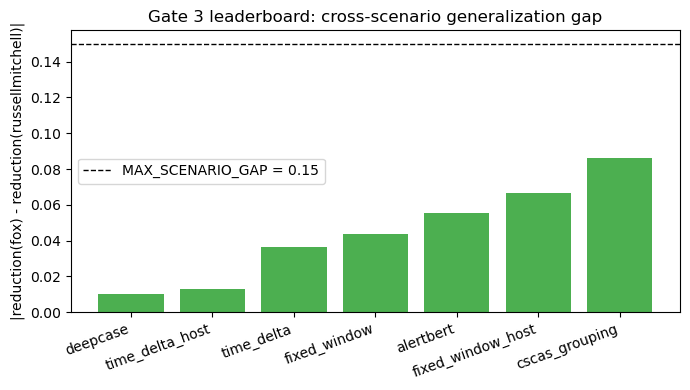

,method,gap
0,deepcase,0.010025
1,time_delta_host,0.013105
2,time_delta,0.036443
3,fixed_window,0.043682
4,alertbert,0.055608
5,fixed_window_host,0.066439
6,cscas_grouping,0.086015


In [69]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate3_df = pd.DataFrame()
else:
    pivot_reduction = best_settings.pivot(index="method", columns="scenario", values="reduction")
    gate3_df = pd.DataFrame({"method": pivot_reduction.index})
    gate3_df["gap"] = (pivot_reduction["fox"] - pivot_reduction["russellmitchell"]).abs().values
    gate3_df = gate3_df.sort_values("gap").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = [GATE_PASS_COLOR if v <= MAX_SCENARIO_GAP else GATE_FAIL_COLOR for v in gate3_df["gap"]]
    ax.bar(gate3_df["method"], gate3_df["gap"], color=colors)
    ax.axhline(MAX_SCENARIO_GAP, color="black", linestyle="--", linewidth=1,
               label=f"MAX_SCENARIO_GAP = {MAX_SCENARIO_GAP:g}")
    ax.set_ylabel("|reduction(fox) - reduction(russellmitchell)|")
    ax.set_title("Gate 3 leaderboard: cross-scenario generalization gap")
    ax.set_xticklabels(gate3_df["method"], rotation=20, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

gate3_df


In [70]:
# LaTeX -- section 10 gate leaderboards (Gate 1-3). Needs \usepackage{booktabs}.
_gate_latex = [
    (gate1_df, ["method", "reduction", "n_groups"], "tab:grouping-gate1",
     "Gate 1 leaderboard --- alert-volume reduction (benefit) and group "
     "count (contrast-mining cost) at each method's jointly-best setting, "
     "mean across scenarios."),
    (gate2_df, ["method", "mixed_frac", "minority_label_exposure", "n_pure_attack_groups"],
     "tab:grouping-gate2",
     "Gate 2 leaderboard --- downstream signal preservation at each "
     "method's jointly-best setting (Mixed / Minority exp.\\ lower is "
     "better, mean across scenarios; pure-attack-group count is the "
     "worst-scenario value, higher is better)."),
    (gate3_df, ["method", "gap"], "tab:grouping-gate3",
     "Gate 3 leaderboard --- absolute reduction gap between \\texttt{fox} "
     "and \\texttt{russellmitchell} at the shared jointly-best setting "
     "(smaller is better)."),
]
for _gdf, _gcols, _glabel, _gcaption in _gate_latex:
    if _gdf is None or _gdf.empty:
        continue
    print(to_latex_table(_gdf[_gcols].set_index("method"), caption=_gcaption,
                         label=_glabel, decimals=4))
    print()

\begin{table}[htbp]
\centering
\small
\caption{Gate 1 leaderboard --- alert-volume reduction (benefit) and group count (contrast-mining cost) at each method's jointly-best setting, mean across scenarios.}
\label{tab:grouping-gate1}
\begin{tabular}{lrr}
\toprule
Method & Reduction & \#groups \\
\midrule
time\_delta\_host & 0.9909 & 954 \\
deepcase & 0.9871 & 2,264 \\
time\_delta & 0.9765 & 2,204 \\
fixed\_window & 0.9706 & 2,956 \\
alertbert & 0.9623 & 3,825 \\
fixed\_window\_host & 0.9540 & 4,833 \\
cscas\_grouping & 0.9441 & 5,298 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\small
\caption{Gate 2 leaderboard --- downstream signal preservation at each method's jointly-best setting (Mixed / Minority exp.\ lower is better, mean across scenarios; pure-attack-group count is the worst-scenario value, higher is better).}
\label{tab:grouping-gate2}
\begin{tabular}{lrrr}
\toprule
Method & Mixed & Minority exp. & \#pure-atk \\
\midrule
alertbert & 0.0002 & 0.1250 & 

### 10.4 Gate 4 -- Operational fit

Deployment facts that don't show up in any accuracy metric but decide
whether a method is actually installable in the target system: GPU
requirement, extra dependencies beyond the plain project `venv`, and whether
the method has a rejection/deferral path (`ungroupable_fraction` > 0 -- only
DeepCASE, confirmed by the section 9 assertion). Facts are keyed by base
method; the per-host split variants inherit them unchanged (the split is a
grouping-logic tweak, not a different dependency profile). Hardcoded from
the notebook intro (cell 1) -- double-check against `run_grouping.sh` /
each script's docstring before the thesis.

Only `REQUIRES_NO_REJECTION` currently gates `passes_operational`; GPU and
extra-deps are reported, not enforced. Turn them into pass conditions here
if the target environment can't provide a GPU or a separate conda env.


In [71]:
# Keyed by BASE method; `*_host` split variants inherit the same facts (the
# split changes grouping logic, not dependencies / hardware / rejection).
# Hardcoded from the notebook intro -- review before treating as final.
_base_deployment_facts = {
    "fixed_window":   {"gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    "time_delta":     {"gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    "cscas_grouping": {"gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    "alertbert":      {"gpu_required": True,  "extra_deps": "separate conda env, graph_tool", "has_rejection_path": False},
    "deepcase":       {"gpu_required": True,  "extra_deps": "torch",                          "has_rejection_path": True},
}


def _deployment_facts_for(method: str) -> dict:
    base = method[:-5] if method.endswith("_host") else method
    facts = _base_deployment_facts.get(base)
    if facts is None:  # unknown method -- surface rather than silently drop
        facts = {"gpu_required": None, "extra_deps": "unknown", "has_rejection_path": False}
    return {"method": method, **facts}


_methods_in_play = (
    sorted(best_settings["method"].unique())
    if not best_settings.empty
    else list(_base_deployment_facts)
)
deployment_facts = pd.DataFrame([_deployment_facts_for(m) for m in _methods_in_play])

if summary_table is None or summary_table.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate4_df = deployment_facts.copy()
else:
    timing = summary_table[["train_time_seconds", "inference_time_seconds"]].reset_index()
    gate4_df = deployment_facts.merge(timing, on="method", how="left")

gate4_df["passes_operational"] = ~(REQUIRES_NO_REJECTION & gate4_df["has_rejection_path"])
gate4_df = gate4_df.sort_values(
    ["passes_operational", "gpu_required", "train_time_seconds"],
    ascending=[False, True, True],
).reset_index(drop=True)

(
    gate4_df.style
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v else GATE_FAIL_COLOR}" for v in col]
           if col.name == "passes_operational" else [""] * len(col))
)


,method,gpu_required,extra_deps,has_rejection_path,train_time_seconds,inference_time_seconds,passes_operational
0,cscas_grouping,False,none (plain venv),False,nan,0.542742,True
1,fixed_window,False,none (plain venv),False,nan,0.186453,True
2,fixed_window_host,False,none (plain venv),False,nan,0.213730,True
3,time_delta,False,none (plain venv),False,nan,0.368702,True
4,time_delta_host,False,none (plain venv),False,nan,0.402716,True
5,deepcase,True,torch,True,175.425784,nan,True
6,alertbert,True,"separate conda env, graph_tool",False,nan,15.790034,True


In [72]:
# LaTeX -- section 10.4 operational fit. Needs \usepackage{booktabs}.
print(to_latex_table(
    gate4_df.reindex(columns=[
        "method", "gpu_required", "extra_deps", "has_rejection_path",
        "train_time_seconds", "inference_time_seconds", "passes_operational",
    ]).set_index("method"),
    caption=(
        "Gate 4 --- operational fit: deployment facts (from the notebook "
        "intro) plus measured train / inference time. \\emph{Op.\\ fit} is "
        "false only when \\texttt{REQUIRES\\_NO\\_REJECTION} and the method "
        "has a rejection path."
    ),
    label="tab:grouping-gate4",
    decimals=2,
))

\begin{table}[htbp]
\centering
\small
\caption{Gate 4 --- operational fit: deployment facts (from the notebook intro) plus measured train / inference time. \emph{Op.\ fit} is false only when \texttt{REQUIRES\_NO\_REJECTION} and the method has a rejection path.}
\label{tab:grouping-gate4}
\begin{tabular}{lrrrrrr}
\toprule
Method & GPU & Extra deps & Rejects? & Train (s) & Infer (s) & Op. fit \\
\midrule
cscas\_grouping & no & none (plain venv) & no & -- & 0.54 & yes \\
fixed\_window & no & none (plain venv) & no & -- & 0.19 & yes \\
fixed\_window\_host & no & none (plain venv) & no & -- & 0.21 & yes \\
time\_delta & no & none (plain venv) & no & -- & 0.37 & yes \\
time\_delta\_host & no & none (plain venv) & no & -- & 0.40 & yes \\
deepcase & yes & torch & yes & 175.4 & -- & yes \\
alertbert & yes & separate conda env, graph\_tool & no & -- & 15.79 & yes \\
\bottomrule
\end{tabular}
\end{table}


## 11. Final integration scorecard

Everything from section 10 combined into a single pass/fail table, with all
four gates applied together. This is the table the "fittable drop-in"
argument rests on: it isn't the highest-reduction method, or the purest
method, in isolation -- it's whichever method(s) clear every gate
simultaneously.


In [73]:
if best_settings.empty or gate1_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    scorecard = pd.DataFrame()
else:
    scorecard = gate1_df.rename(
        columns={"reduction": "reduction_mean", "n_groups": "n_groups_mean"}
    )
    scorecard["passes_reduction"] = scorecard["reduction_mean"] >= MIN_REDUCTION

    scorecard = scorecard.merge(gate2_df, on="method")
    # 2b only applies where mixed_frac is high enough for
    # minority_label_exposure to be a real measurement (see cell 39).
    _passes_2b = (scorecard["mixed_frac"] <= MIN_MIXED_FRAC_FOR_EXPOSURE) | (
        scorecard["minority_label_exposure"] <= MAX_MINORITY_LABEL_EXPOSURE
    )
    scorecard["passes_purity"] = (
        (scorecard["mixed_frac"] <= MAX_MIXED_FRAC)       # 2a
        & _passes_2b                                       # 2b (conditional)
        & (scorecard["n_pure_attack_groups"] >= MIN_PURE_ATTACK_GROUPS)  # 2c
    )

    scorecard = scorecard.merge(gate3_df, on="method")
    scorecard["passes_generalization"] = scorecard["gap"] <= MAX_SCENARIO_GAP

    scorecard = scorecard.merge(
        gate4_df[["method", "gpu_required", "extra_deps", "has_rejection_path", "passes_operational"]],
        on="method",
    )

    gate_cols = ["passes_reduction", "passes_purity", "passes_generalization", "passes_operational"]
    scorecard["n_gates_passed"] = scorecard[gate_cols].sum(axis=1)
    scorecard["verdict"] = np.where(
        scorecard[gate_cols].all(axis=1), "candidate", "eliminated"
    )

    scorecard = scorecard.sort_values(
        ["verdict", "n_gates_passed", "reduction_mean"], ascending=[True, False, False]
    ).reset_index(drop=True)

    candidates = scorecard.loc[scorecard["verdict"] == "candidate", "method"].tolist()
    if candidates:
        print(f"Candidates surviving all four gates: {candidates}")
    else:
        print("No method survives all four gates at the current thresholds -- "
              "revisit thresholds or consider a hybrid/fallback strategy.")

display_cols = ["method", "reduction_mean", "n_groups_mean", "passes_reduction",
                 "mixed_frac", "minority_label_exposure", "n_pure_attack_groups", "passes_purity",
                 "gap", "passes_generalization",
                 "gpu_required", "extra_deps", "has_rejection_path", "passes_operational",
                 "n_gates_passed", "verdict"]

(
    scorecard[display_cols].style
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v else GATE_FAIL_COLOR}" for v in col]
           if col.name.startswith("passes_") else [""] * len(col))
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v == 'candidate' else GATE_FAIL_COLOR}" for v in col]
           if col.name == "verdict" else [""] * len(col))
)


Candidates surviving all four gates: ['deepcase', 'fixed_window', 'alertbert', 'fixed_window_host', 'cscas_grouping']


,method,reduction_mean,n_groups_mean,passes_reduction,mixed_frac,minority_label_exposure,n_pure_attack_groups,passes_purity,gap,passes_generalization,gpu_required,extra_deps,has_rejection_path,passes_operational,n_gates_passed,verdict
0,deepcase,0.987140,2263.500000,True,0.011772,0.015460,174.000000,True,0.010025,True,True,torch,True,True,4,candidate
1,fixed_window,0.970594,2956.500000,True,0.000568,0.204762,60.000000,True,0.043682,True,False,none (plain venv),False,True,4,candidate
2,alertbert,0.962329,3825.000000,True,0.000214,0.125000,76.000000,True,0.055608,True,True,"separate conda env, graph_tool",False,True,4,candidate
3,fixed_window_host,0.953978,4833.000000,True,0.000139,0.250000,110.000000,True,0.066439,True,False,none (plain venv),False,True,4,candidate
4,cscas_grouping,0.944114,5298.500000,True,0.000526,0.409420,198.000000,True,0.086015,True,False,none (plain venv),False,True,4,candidate
5,time_delta_host,0.990919,954.000000,True,0.006438,0.177755,24.000000,False,0.013105,True,False,none (plain venv),False,True,3,eliminated
6,time_delta,0.976482,2203.500000,True,0.000862,0.380260,45.000000,False,0.036443,True,False,none (plain venv),False,True,3,eliminated


In [74]:
# LaTeX -- section 11 integration scorecard. Needs \usepackage{booktabs} and
# \usepackage{graphicx} (for \resizebox). GPU / dependency / rejection-path
# columns are dropped here -- they're in the Gate 4 table.
if not scorecard.empty:
    print(to_latex_table(
        scorecard.reindex(columns=[
            "method", "reduction_mean", "n_groups_mean", "passes_reduction",
            "mixed_frac", "minority_label_exposure", "n_pure_attack_groups", "passes_purity",
            "gap", "passes_generalization", "passes_operational",
            "n_gates_passed", "verdict",
        ]).set_index("method"),
        caption=(
            "Final integration scorecard: all four gates applied together. "
            "GPU / dependency / rejection-path detail is in "
            "Table~\\ref{tab:grouping-gate4}."
        ),
        label="tab:grouping-scorecard",
        resizebox=True,
        decimals=4,
    ))

\begin{table}[htbp]
\centering
\small
\caption{Final integration scorecard: all four gates applied together. GPU / dependency / rejection-path detail is in Table~\ref{tab:grouping-gate4}.}
\label{tab:grouping-scorecard}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
Method & Reduction & \#groups & G1 & Mixed & Minority exp. & \#pure-atk & G2 & Gap & G3 & Op. fit & \#gates & Verdict \\
\midrule
deepcase & 0.9871 & 2,264 & yes & 0.0118 & 0.0155 & 174 & yes & 0.0100 & yes & yes & 4 & candidate \\
fixed\_window & 0.9706 & 2,956 & yes & 0.0006 & 0.2048 & 60 & yes & 0.0437 & yes & yes & 4 & candidate \\
alertbert & 0.9623 & 3,825 & yes & 0.0002 & 0.1250 & 76 & yes & 0.0556 & yes & yes & 4 & candidate \\
fixed\_window\_host & 0.9540 & 4,833 & yes & 0.0001 & 0.2500 & 110 & yes & 0.0664 & yes & yes & 4 & candidate \\
cscas\_grouping & 0.9441 & 5,298 & yes & 0.0005 & 0.4094 & 198 & yes & 0.0860 & yes & yes & 4 & candidate \\
time\_delta\_host & 0.9909 & 954 & yes & 0.0064 & 

In [75]:
scorecard.to_csv("grouping_integration_scorecard.csv", index=False)


## 12. Per-setting comparison across methods

A single figure comparing all seven grouping variants (host-split variants
included) across their **full** parameter sweep, aggregated across both
held-out scenarios -- a complement to sections 9-11's single-best-setting
view. Bars within a method cluster are one per tested setting, with
adjacent settings (in parameter order) collapsed into one bar wherever
their value on that panel's metric differs by less than 1% relative, so
methods with dense grids (time-delta's 42 deltas, AlertBERT's 39 pairs)
stay legible.

The fourth panel is a new metric, independent of sections 9-11's
selection guards: for each setting, how many more *balanced pure groups*
-- $\min(n_\text{pure-attack}, n_\text{pure-benign})$, i.e. groups that
are single-label, capped by whichever class is scarcer -- a same-method
setting with a comparable group count (within +-10%) could have delivered
on whichever of the two scenarios performs worse. Anchoring the
comparison to group count (not reduction) is deliberate: mining cost is
$O(\text{groups})$, so it is the natural axis for "costs about the same
to mine"; a reduction-based band was tried first and found too wide for
AlertBERT/DeepCASE, whose reduction is nearly flat across much of their
sweep. This metric only captures label purity, not signature coherence
-- a setting with zero mixed groups can still mix many different
signatures within a pure group without being penalised here.

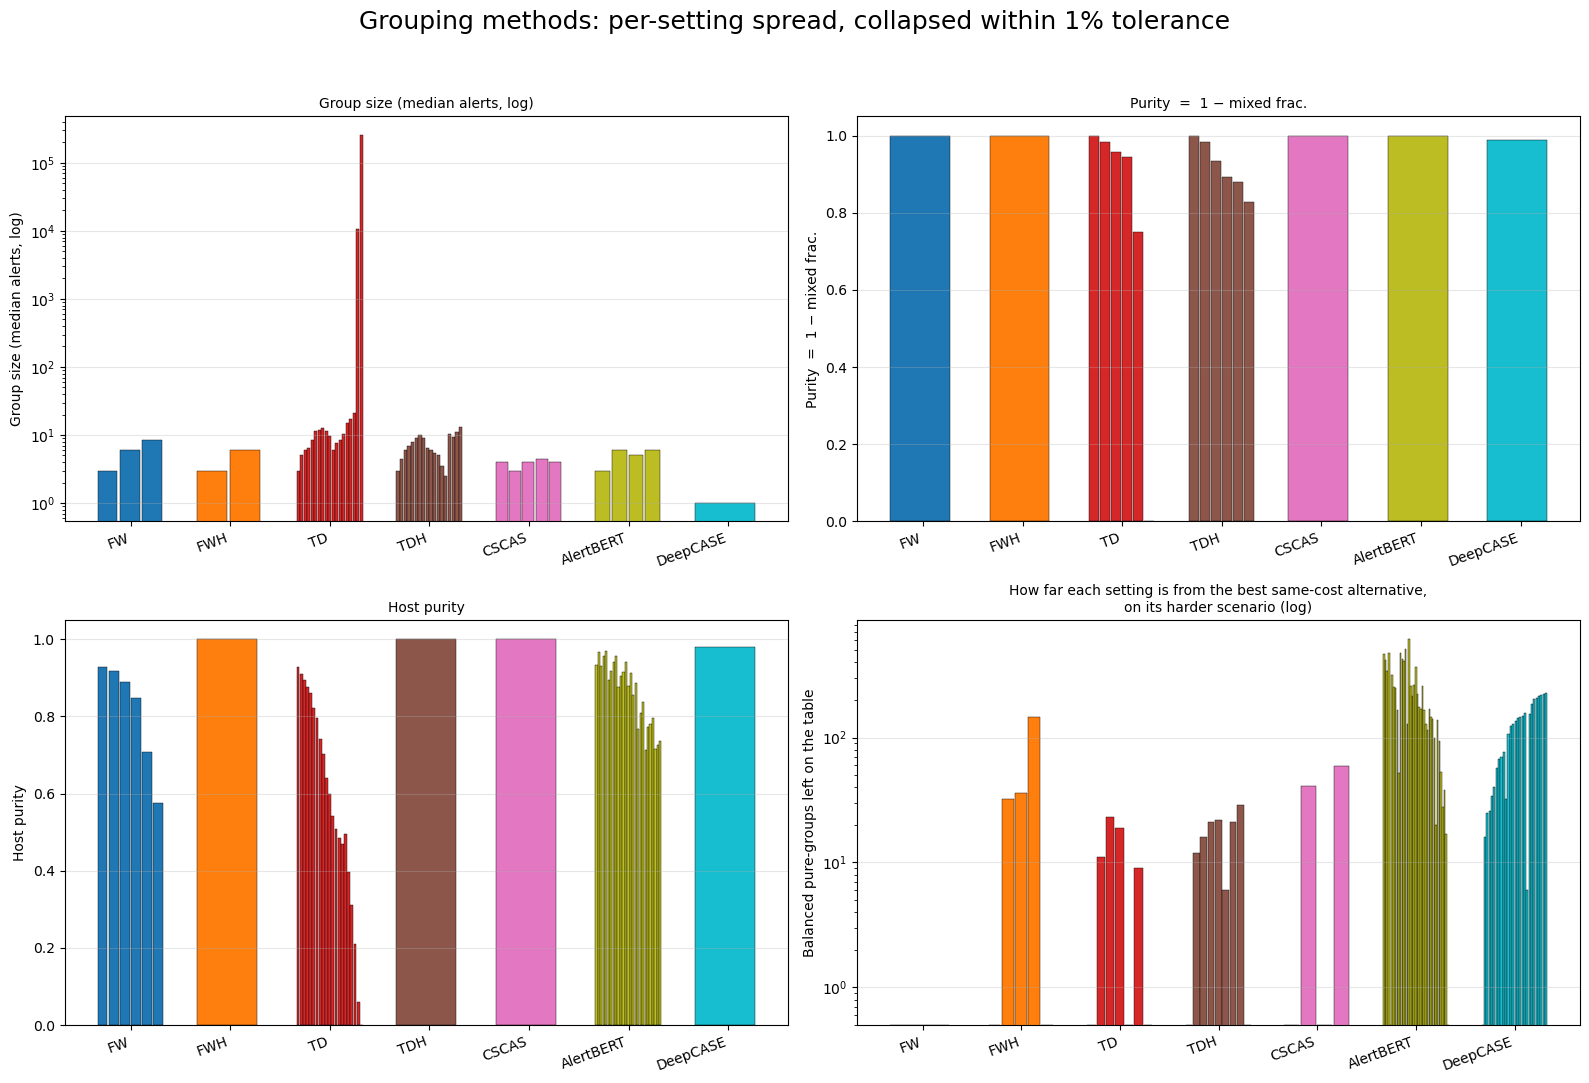

In [76]:
NG_TOL = 0.10  # +-10% group-count band for "costs about the same to mine"

def _balanced_pure(df):
    d = df.copy()
    d["purity"] = 1.0 - d["mixed_frac"]
    d["n_pure_attack"] = (d["n_groups"] * d["pure_attack_frac"]).round().astype(int)
    d["n_pure_benign"] = (d["n_groups"] * d["pure_benign_frac"]).round().astype(int)
    d["balanced_pure"] = np.minimum(d["n_pure_attack"], d["n_pure_benign"])
    return d

def _per_setting(df, order_cols):
    """One row per setting: mean group_size_median/purity/host_purity across
    scenarios, plus the worst-case (over scenarios) balanced-pure regret
    against the best same-group-count (+-NG_TOL) alternative."""
    d = _balanced_pure(df)
    agg = d.groupby("param", as_index=False).agg(
        group_size_median=("group_size_median", "mean"),
        purity=("purity", "mean"),
        host_purity=("host_purity", "mean"),
    )
    regret = []
    for p in agg["param"]:
        worst = 0.0
        for scen in ("fox", "russellmitchell"):
            sub = d[d.scenario == scen]
            row = sub[sub.param == p]
            if row.empty:
                continue
            row = row.iloc[0]
            lo, hi = row.n_groups * (1 - NG_TOL), row.n_groups * (1 + NG_TOL)
            band = sub[sub.n_groups.between(lo, hi)]
            own_best = band.balanced_pure.max() if len(band) else row.balanced_pure
            worst = max(worst, max(0.0, own_best - row.balanced_pure))
        regret.append(worst)
    agg["regret"] = regret
    ref = d.drop_duplicates("param")[["param", *order_cols]].sort_values(order_cols)
    agg = agg.set_index("param").loc[ref["param"]].reset_index()
    return agg

_method_frames = {}
if "fixed_window" in results_dfs:
    _fw = results_dfs["fixed_window"].assign(_w=lambda x: x["param"].astype(int))
    _method_frames["fixed_window"] = (_fw[_fw.method == "fixed_window"], ["_w"])
    _method_frames["fixed_window_host"] = (_fw[_fw.method == "fixed_window_host"], ["_w"])
if "time_delta" in results_dfs:
    _td = results_dfs["time_delta"]
    _method_frames["time_delta"] = (_td[_td.method == "time_delta"], ["delta"])
    _method_frames["time_delta_host"] = (_td[_td.method == "time_delta_host"], ["delta"])
if not cscas_sensitivity_df.empty:
    _cs = cscas_sensitivity_df.drop_duplicates(
        subset=["scenario", "session_length", "session_timeout"]
    )
    _method_frames["cscas_grouping"] = (_cs, ["session_length", "session_timeout"])
if "alertbert" in results_dfs:
    _method_frames["alertbert"] = (results_dfs["alertbert"], ["delta", "theta"])
if "deepcase" in results_dfs:
    _method_frames["deepcase"] = (results_dfs["deepcase"], ["context_length", "eps"])

_method_order = [m for m in
                  ["fixed_window", "fixed_window_host", "time_delta", "time_delta_host",
                   "cscas_grouping", "alertbert", "deepcase"]
                  if m in _method_frames]
_method_label = {"fixed_window": "FW", "fixed_window_host": "FWH",
                  "time_delta": "TD", "time_delta_host": "TDH",
                  "cscas_grouping": "CSCAS", "alertbert": "AlertBERT", "deepcase": "DeepCASE"}

if not _method_order:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    _combined = {m: _per_setting(df, cols) for m, (df, cols) in _method_frames.items()}

    _TOL = 0.01
    def _collapse(values):
        runs, cur = [], [values[0]]
        for v in values[1:]:
            run_mean = np.mean(cur)
            if abs(v - run_mean) / max(abs(run_mean), 1e-12) <= _TOL:
                cur.append(v)
            else:
                runs.append(np.mean(cur))
                cur = [v]
        runs.append(np.mean(cur))
        return runs

    _panels = [
        ("group_size_median", "Group size (median alerts, log)", True),
        ("purity", "Purity  =  1 \u2212 mixed frac.", False),
        ("host_purity", "Host purity", False),
        ("regret",
         "How far each setting is from the best same-cost alternative,\non its harder scenario (log)",
         True),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()
    _colors = plt.cm.tab10(np.linspace(0, 1, len(_method_order)))
    _method_color = dict(zip(_method_order, _colors))
    _REGRET_FLOOR = 0.5

    for ax, (col, title, logy) in zip(axes, _panels):
        xpos, centers = 0.0, []
        for m in _method_order:
            vals = _combined[m][col].to_numpy()
            runs = _collapse(vals)
            n = len(runs)
            width, bw = 0.8, 0.8 / n
            for i, h in enumerate(runs):
                hh = max(h, _REGRET_FLOOR) if (col == "regret" and h <= 0) else h
                ax.bar(xpos + i * bw, hh, width=bw * 0.9, color=_method_color[m],
                       align="edge", edgecolor="black", linewidth=0.3)
            centers.append(xpos + width / 2)
            xpos += width + 0.4
        ax.set_xticks(centers)
        ax.set_xticklabels([_method_label[m] for m in _method_order], rotation=20, ha="right")
        ax.set_title(title, fontsize=10)
        ax.set_ylabel("Balanced pure-groups left on the table" if col == "regret" else title.split("\n")[0])
        if logy:
            ax.set_yscale("log")
            if col == "regret":
                ax.set_ylim(bottom=_REGRET_FLOOR)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Grouping methods: per-setting spread, collapsed within 1% tolerance", fontsize=18)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
